# 1 Load & Understand the Dataset

In [ ]:
dl <- read.csv("/content/data.csv")

# 2 Data Cleaning

In [ ]:
names(dl) <- toupper(names(dl))
print(names(dl))  # Convert column names to uppercase

 [1] "ID"                      "DIAGNOSIS"              
 [3] "RADIUS_MEAN"             "TEXTURE_MEAN"           
 [5] "PERIMETER_MEAN"          "AREA_MEAN"              
 [7] "SMOOTHNESS_MEAN"         "COMPACTNESS_MEAN"       
 [9] "CONCAVITY_MEAN"          "CONCAVE.POINTS_MEAN"    
[11] "SYMMETRY_MEAN"           "FRACTAL_DIMENSION_MEAN" 
[13] "RADIUS_SE"               "TEXTURE_SE"             
[15] "PERIMETER_SE"            "AREA_SE"                
[17] "SMOOTHNESS_SE"           "COMPACTNESS_SE"         
[19] "CONCAVITY_SE"            "CONCAVE.POINTS_SE"      
[21] "SYMMETRY_SE"             "FRACTAL_DIMENSION_SE"   
[23] "RADIUS_WORST"            "TEXTURE_WORST"          
[25] "PERIMETER_WORST"         "AREA_WORST"             
[27] "SMOOTHNESS_WORST"        "COMPACTNESS_WORST"      
[29] "CONCAVITY_WORST"         "CONCAVE.POINTS_WORST"   
[31] "SYMMETRY_WORST"          "FRACTAL_DIMENSION_WORST"
[33] "X"                      


In [ ]:
names(dl) <- tolower(names(dl))
print(names(dl))  # Convert column names to lowercase

 [1] "id"                      "diagnosis"              
 [3] "radius_mean"             "texture_mean"           
 [5] "perimeter_mean"          "area_mean"              
 [7] "smoothness_mean"         "compactness_mean"       
 [9] "concavity_mean"          "concave.points_mean"    
[11] "symmetry_mean"           "fractal_dimension_mean" 
[13] "radius_se"               "texture_se"             
[15] "perimeter_se"            "area_se"                
[17] "smoothness_se"           "compactness_se"         
[19] "concavity_se"            "concave.points_se"      
[21] "symmetry_se"             "fractal_dimension_se"   
[23] "radius_worst"            "texture_worst"          
[25] "perimeter_worst"         "area_worst"             
[27] "smoothness_worst"        "compactness_worst"      
[29] "concavity_worst"         "concave.points_worst"   
[31] "symmetry_worst"          "fractal_dimension_worst"
[33] "x"                      


In [ ]:
# Count missing values in each column
missing_values <- colSums(is.na(dl))
print(missing_values)

                     id               diagnosis             radius_mean 
                      0                       0                       0 
           texture_mean          perimeter_mean               area_mean 
                      0                       0                       0 
        smoothness_mean        compactness_mean          concavity_mean 
                      0                       0                       0 
    concave.points_mean           symmetry_mean  fractal_dimension_mean 
                      0                       0                       0 
              radius_se              texture_se            perimeter_se 
                      0                       0                       0 
                area_se           smoothness_se          compactness_se 
                      0                       0                       0 
           concavity_se       concave.points_se             symmetry_se 
                      0                       0    

In [ ]:
# Remove the X column because it contains only NA values
if ("x" %in% names(dl)) {
  dl$x <- NULL
}

# Check missing values again
print(colSums(is.na(dl)))


                     id               diagnosis             radius_mean 
                      0                       0                       0 
           texture_mean          perimeter_mean               area_mean 
                      0                       0                       0 
        smoothness_mean        compactness_mean          concavity_mean 
                      0                       0                       0 
    concave.points_mean           symmetry_mean  fractal_dimension_mean 
                      0                       0                       0 
              radius_se              texture_se            perimeter_se 
                      0                       0                       0 
                area_se           smoothness_se          compactness_se 
                      0                       0                       0 
           concavity_se       concave.points_se             symmetry_se 
                      0                       0    

In [ ]:
# Count duplicate rows
duplicate_count <- sum(duplicated(dl))
print(paste("Number of duplicate rows:", duplicate_count))

# Remove exact duplicate rows
dl <- dl[!duplicated(dl), ]

[1] "Number of duplicate rows: 0"


In [ ]:
# Convert diagnosis from character to factor
dl$diagnosis <- as.factor(dl$diagnosis)

# Convert id to numeric if necessary
dl$id <- as.numeric(dl$id)

In [ ]:
str(dl) # Inspect data types and structure

'data.frame':	569 obs. of  32 variables:
 $ id                     : num  842302 842517 84300903 84348301 84358402 ...
 $ diagnosis              : Factor w/ 2 levels "B","M": 2 2 2 2 2 2 2 2 2 2 ...
 $ radius_mean            : num  18 20.6 19.7 11.4 20.3 ...
 $ texture_mean           : num  10.4 17.8 21.2 20.4 14.3 ...
 $ perimeter_mean         : num  122.8 132.9 130 77.6 135.1 ...
 $ area_mean              : num  1001 1326 1203 386 1297 ...
 $ smoothness_mean        : num  0.1184 0.0847 0.1096 0.1425 0.1003 ...
 $ compactness_mean       : num  0.2776 0.0786 0.1599 0.2839 0.1328 ...
 $ concavity_mean         : num  0.3001 0.0869 0.1974 0.2414 0.198 ...
 $ concave.points_mean    : num  0.1471 0.0702 0.1279 0.1052 0.1043 ...
 $ symmetry_mean          : num  0.242 0.181 0.207 0.26 0.181 ...
 $ fractal_dimension_mean : num  0.0787 0.0567 0.06 0.0974 0.0588 ...
 $ radius_se              : num  1.095 0.543 0.746 0.496 0.757 ...
 $ texture_se             : num  0.905 0.734 0.787 1.156 0.781 .

In [ ]:
sum(is.na(dl)) # Total missing value count

[1] 0

In [ ]:
# Remove extra whitespace and standardize case
dl$diagnosis <- trimws(dl$diagnosis)
dl$diagnosis <- toupper(dl$diagnosis)

In [ ]:
# Check unique categories
print(unique(dl$diagnosis))

[1] M B
Levels: B M


In [ ]:
# Check final dimensions
print(dim(dl))

[1] 569  32


In [ ]:
# Display cleaned data
head(dl)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave.points_mean,⋯,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave.points_worst,symmetry_worst,fractal_dimension_worst
,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,⋯,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
2,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,⋯,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
3,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,⋯,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
4,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,⋯,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
5,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,⋯,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
6,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,⋯,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


# 3 Data Preprocessing

In [ ]:
install.packages("caret")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




In [ ]:
library(caret)

In [ ]:
# Statistical Summary of Every Column
summary(dl)

       id            diagnosis  radius_mean      texture_mean  
 Min.   :     8670   B:357     Min.   : 6.981   Min.   : 9.71  
 1st Qu.:   869218   M:212     1st Qu.:11.700   1st Qu.:16.17  
 Median :   906024             Median :13.370   Median :18.84  
 Mean   : 30371831             Mean   :14.127   Mean   :19.29  
 3rd Qu.:  8813129             3rd Qu.:15.780   3rd Qu.:21.80  
 Max.   :911320502             Max.   :28.110   Max.   :39.28  
 perimeter_mean     area_mean      smoothness_mean   compactness_mean 
 Min.   : 43.79   Min.   : 143.5   Min.   :0.05263   Min.   :0.01938  
 1st Qu.: 75.17   1st Qu.: 420.3   1st Qu.:0.08637   1st Qu.:0.06492  
 Median : 86.24   Median : 551.1   Median :0.09587   Median :0.09263  
 Mean   : 91.97   Mean   : 654.9   Mean   :0.09636   Mean   :0.10434  
 3rd Qu.:104.10   3rd Qu.: 782.7   3rd Qu.:0.10530   3rd Qu.:0.13040  
 Max.   :188.50   Max.   :2501.0   Max.   :0.16340   Max.   :0.34540  
 concavity_mean    concave.points_mean symmetry_mean   

In [ ]:
# Dimension Check
dim(dl)

print(paste(
  "Rows:", nrow(dl),
  "Columns:", ncol(dl)
))

[1] 569  32

[1] "Rows: 569 Columns: 32"


In [ ]:
#  Head/Tail Preview
head(dl)
tail(dl)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave.points_mean,⋯,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave.points_worst,symmetry_worst,fractal_dimension_worst
,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,⋯,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
2,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,⋯,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
3,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,⋯,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
4,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,⋯,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
5,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,⋯,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
6,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,⋯,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave.points_mean,⋯,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave.points_worst,symmetry_worst,fractal_dimension_worst
,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
564,926125,M,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.14740,⋯,24.290,29.41,179.10,1819.0,0.14070,0.41860,0.6599,0.2542,0.2929,0.09873
565,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,⋯,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
566,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,⋯,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
567,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,⋯,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
568,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,⋯,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
569,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,⋯,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [ ]:
# 5. Per-Column Data Type Check
sapply(dl, class)

id               diagnosis             radius_mean 
              "numeric"                "factor"               "numeric" 
           texture_mean          perimeter_mean               area_mean 
              "numeric"               "numeric"               "numeric" 
        smoothness_mean        compactness_mean          concavity_mean 
              "numeric"               "numeric"               "numeric" 
    concave.points_mean           symmetry_mean  fractal_dimension_mean 
              "numeric"               "numeric"               "numeric" 
              radius_se              texture_se            perimeter_se 
              "numeric"               "numeric"               "numeric" 
                area_se           smoothness_se          compactness_se 
              "numeric"               "numeric"               "numeric" 
           concavity_se       concave.points_se             symmetry_se 
              "numeric"               "numeric"               "numeric" 
   fractal_dimension_se            radius_worst           texture_worst 
              "numeric"               "numeric"               "numeric" 
        perimeter_worst              area_worst        smoothness_worst 
              "numeric"               "numeric"               "numeric" 
      compactness_worst         concavity_worst    concave.points_worst 
              "numeric"               "numeric"               "numeric" 
         symmetry_worst fractal_dimension_worst 
              "numeric"               "numeric"

In [ ]:
# Select only numeric columns
numeric_data <- dl[
  ,
  sapply(dl, is.numeric),
  drop = FALSE
]

# Display numeric data
print(head(numeric_data))

        id radius_mean texture_mean perimeter_mean area_mean smoothness_mean
1   842302       17.99        10.38         122.80    1001.0         0.11840
2   842517       20.57        17.77         132.90    1326.0         0.08474
3 84300903       19.69        21.25         130.00    1203.0         0.10960
4 84348301       11.42        20.38          77.58     386.1         0.14250
5 84358402       20.29        14.34         135.10    1297.0         0.10030
6   843786       12.45        15.70          82.57     477.1         0.12780
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1          0.27760         0.3001             0.14710        0.2419
2          0.07864         0.0869             0.07017        0.1812
3          0.15990         0.1974             0.12790        0.2069
4          0.28390         0.2414             0.10520        0.2597
5          0.13280         0.1980             0.10430        0.1809
6          0.17000         0.1578             0.08089

In [ ]:
# Identify zero- or near-zero-variance columns
nzv_columns <- nearZeroVar(
  numeric_data,
  saveMetrics = TRUE
)

print(nzv_columns)

                        freqRatio percentUnique zeroVar   nzv
id                       1.000000     100.00000   FALSE FALSE
radius_mean              1.333333      80.14060   FALSE FALSE
texture_mean             1.000000      84.18278   FALSE FALSE
perimeter_mean           1.000000      91.73989   FALSE FALSE
area_mean                1.500000      94.72759   FALSE FALSE
smoothness_mean          1.250000      83.30404   FALSE FALSE
compactness_mean         1.000000      94.37610   FALSE FALSE
concavity_mean           4.333333      94.37610   FALSE FALSE
concave.points_mean      4.333333      95.25483   FALSE FALSE
symmetry_mean            1.000000      75.92267   FALSE FALSE
fractal_dimension_mean   1.000000      87.69772   FALSE FALSE
radius_se                1.000000      94.90334   FALSE FALSE
texture_se               1.000000      91.21265   FALSE FALSE
perimeter_se             2.000000      93.67311   FALSE FALSE
area_se                  1.000000      92.79438   FALSE FALSE
smoothne

In [ ]:
# Create dummy variables for diagnosis
dummy_model <- dummyVars(
  diagnosis ~ .,
  data = dl
)


In [ ]:
# Convert data into numeric format
encoded_data <- predict(
  dummy_model,
  newdata = dl
)


Warning message in model.frame.default(Terms, newdata, na.action = na.action, xlev = object$lvls):
“variable 'diagnosis' is not a factor”


In [ ]:
# Convert matrix to data frame
encoded_data <- as.data.frame(encoded_data)

In [ ]:
# Display final preprocessed data
head(encoded_data)

# Check structure
str(encoded_data)

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave.points_mean,symmetry_mean,⋯,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave.points_worst,symmetry_worst,fractal_dimension_worst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,⋯,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
2,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,⋯,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
3,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,⋯,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
4,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,⋯,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
5,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,⋯,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
6,843786,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,⋯,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


'data.frame':	569 obs. of  31 variables:
 $ id                     : num  842302 842517 84300903 84348301 84358402 ...
 $ radius_mean            : num  18 20.6 19.7 11.4 20.3 ...
 $ texture_mean           : num  10.4 17.8 21.2 20.4 14.3 ...
 $ perimeter_mean         : num  122.8 132.9 130 77.6 135.1 ...
 $ area_mean              : num  1001 1326 1203 386 1297 ...
 $ smoothness_mean        : num  0.1184 0.0847 0.1096 0.1425 0.1003 ...
 $ compactness_mean       : num  0.2776 0.0786 0.1599 0.2839 0.1328 ...
 $ concavity_mean         : num  0.3001 0.0869 0.1974 0.2414 0.198 ...
 $ concave.points_mean    : num  0.1471 0.0702 0.1279 0.1052 0.1043 ...
 $ symmetry_mean          : num  0.242 0.181 0.207 0.26 0.181 ...
 $ fractal_dimension_mean : num  0.0787 0.0567 0.06 0.0974 0.0588 ...
 $ radius_se              : num  1.095 0.543 0.746 0.496 0.757 ...
 $ texture_se             : num  0.905 0.734 0.787 1.156 0.781 ...
 $ perimeter_se           : num  8.59 3.4 4.58 3.44 5.44 ...
 $ area_se      

# 4 Exploratory Data Analysis — Non-Graphical

In [ ]:
# Unique Value Counts
unique_counts <- sapply(
  dl,
  function(x) length(unique(x))
)

print(unique_counts)


                     id               diagnosis             radius_mean 
                    569                       2                     456 
           texture_mean          perimeter_mean               area_mean 
                    479                     522                     539 
        smoothness_mean        compactness_mean          concavity_mean 
                    474                     537                     537 
    concave.points_mean           symmetry_mean  fractal_dimension_mean 
                    542                     432                     499 
              radius_se              texture_se            perimeter_se 
                    540                     519                     533 
                area_se           smoothness_se          compactness_se 
                    528                     547                     541 
           concavity_se       concave.points_se             symmetry_se 
                    533                     507    

In [ ]:
#  Frequency Tables
table(dl$diagnosis)


  B   M 
357 212 

In [ ]:
# Cross-Tabulation
table(
  dl$diagnosis,
  useNA = "ifany"
)


  B   M 
357 212 

In [ ]:
# Mean radius grouped by diagnosis
aggregate(
  radius_mean ~ diagnosis,
  data = dl,
  FUN = mean
)


diagnosis,radius_mean
<fct>,<dbl>
B,12.14652
M,17.46283


In [ ]:
# Multiple grouped statistics
aggregate(
  cbind(
    radius_mean,
    texture_mean,
    area_mean
  ) ~ diagnosis,
  data = dl,
  mean
)


diagnosis,radius_mean,texture_mean,area_mean
<fct>,<dbl>,<dbl>,<dbl>
B,12.14652,17.91476,462.7902
M,17.46283,21.60491,978.3764


In [ ]:
# Rich Per-Column Profile
if (!requireNamespace("skimr", quietly = TRUE)) {
  install.packages(
    "skimr",
  )
}

library(skimr)

skim(dl)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



,skim_type,skim_variable,n_missing,complete_rate,factor.ordered,factor.n_unique,factor.top_counts,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<lgl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,factor,diagnosis,0,1,FALSE,2,"B: 357, M: 212",NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,id,0,1,NA,NA,NA,3.037183e+07,1.250206e+08,8.670e+03,8.69218e+05,9.06024e+05,8.813129e+06,9.113205e+08,▇▁▁▁▁
3,numeric,radius_mean,0,1,NA,NA,NA,1.412729e+01,3.524049e+00,6.981e+00,1.17000e+01,1.33700e+01,1.578000e+01,2.811000e+01,▂▇▃▁▁
4,numeric,texture_mean,0,1,NA,NA,NA,1.928965e+01,4.301036e+00,9.710e+00,1.61700e+01,1.88400e+01,2.180000e+01,3.928000e+01,▃▇▃▁▁
5,numeric,perimeter_mean,0,1,NA,NA,NA,9.196903e+01,2.429898e+01,4.379e+01,7.51700e+01,8.62400e+01,1.041000e+02,1.885000e+02,▃▇▃▁▁
6,numeric,area_mean,0,1,NA,NA,NA,6.548891e+02,3.519141e+02,1.435e+02,4.20300e+02,5.51100e+02,7.827000e+02,2.501000e+03,▇▃▂▁▁
7,numeric,smoothness_mean,0,1,NA,NA,NA,9.636028e-02,1.406413e-02,5.263e-02,8.63700e-02,9.58700e-02,1.053000e-01,1.634000e-01,▁▇▇▁▁
8,numeric,compactness_mean,0,1,NA,NA,NA,1.043410e-01,5.281276e-02,1.938e-02,6.49200e-02,9.26300e-02,1.304000e-01,3.454000e-01,▇▇▂▁▁
9,numeric,concavity_mean,0,1,NA,NA,NA,8.879932e-02,7.971981e-02,0.000e+00,2.95600e-02,6.15400e-02,1.307000e-01,4.268000e-01,▇▃▂▁▁


In [ ]:
# Install psych if necessary
if (!requireNamespace("psych", quietly = TRUE)) {
  install.packages(
    "psych",
  )
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘mnormt’, ‘GPArotation’




In [ ]:
library(psych)

# Describe numeric columns only
numeric_data <- dl[
  ,
  sapply(dl, is.numeric),
  drop = FALSE
]

describe(numeric_data)


Attaching package: ‘psych’


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha




,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
id,1,569,3.037183e+07,1.250206e+08,9.06024e+05,7.344333e+06,6.556799e+04,8.670e+03,9.113205e+08,9.113118e+08,6.4396595,41.6554369,5.241136e+06
radius_mean,2,569,1.412729e+01,3.524049e+00,1.33700e+01,1.381991e+01,2.816940e+00,6.981e+00,2.811000e+01,2.112900e+01,0.9374168,0.8141418,1.477358e-01
texture_mean,3,569,1.928965e+01,4.301036e+00,1.88400e+01,1.903779e+01,4.166106e+00,9.710e+00,3.928000e+01,2.957000e+01,0.6470241,0.7280071,1.803088e-01
perimeter_mean,4,569,9.196903e+01,2.429898e+01,8.62400e+01,8.974046e+01,1.884385e+01,4.379e+01,1.885000e+02,1.447100e+02,0.9854334,0.9392821,1.018666e+00
area_mean,5,569,6.548891e+02,3.519141e+02,5.51100e+02,6.061278e+02,2.272826e+02,1.435e+02,2.501000e+03,2.357500e+03,1.6370654,3.5865488,1.475301e+01
smoothness_mean,6,569,9.636028e-02,1.406413e-02,9.58700e-02,9.587740e-02,1.408470e-02,5.263e-02,1.634000e-01,1.107700e-01,0.4539207,0.8244671,5.895989e-04
compactness_mean,7,569,1.043410e-01,5.281276e-02,9.26300e-02,9.808295e-02,4.837724e-02,1.938e-02,3.454000e-01,3.260200e-01,1.1838556,1.6088967,2.214026e-03
concavity_mean,8,569,8.879932e-02,7.971981e-02,6.15400e-02,7.725070e-02,5.998600e-02,0.000e+00,4.268000e-01,4.268000e-01,1.3938008,1.9531357,3.342028e-03
concave.points_mean,9,569,4.891915e-02,3.880284e-02,3.35000e-02,4.400013e-02,2.985956e-02,0.000e+00,2.012000e-01,2.012000e-01,1.1650124,1.0324689,1.626700e-03


In [ ]:
# 13. Correlation Matrix
correlation_matrix <- cor(
  numeric_data,
  use = "complete.obs"
)

print(correlation_matrix)

                                   id  radius_mean texture_mean perimeter_mean
id                       1.0000000000  0.074626470  0.099769891    0.073159412
radius_mean              0.0746264697  1.000000000  0.323781891    0.997855281
texture_mean             0.0997698912  0.323781891  1.000000000    0.329533059
perimeter_mean           0.0731594119  0.997855281  0.329533059    1.000000000
area_mean                0.0968928233  0.987357170  0.321085696    0.986506804
smoothness_mean         -0.0129681975  0.170581187 -0.023388516    0.207278164
compactness_mean         0.0000957011  0.506123578  0.236702222    0.556936211
concavity_mean           0.0500799532  0.676763550  0.302417828    0.716135650
concave.points_mean      0.0441580956  0.822528522  0.293464051    0.850977041
symmetry_mean           -0.0221140609  0.147741242  0.071400980    0.183027212
fractal_dimension_mean  -0.0525114476 -0.311630826 -0.076437183   -0.261476908
radius_se                0.1430475814  0.679090388  

In [ ]:
# Install caret if necessary
if (!requireNamespace("caret", quietly = TRUE)) {
  install.packages(
    "caret",
  )
}

library(caret)

nzv_result <- nearZeroVar(       # Non-Zero Varience check
  numeric_data,
  saveMetrics = TRUE
)

print(nzv_result)

                        freqRatio percentUnique zeroVar   nzv
id                       1.000000     100.00000   FALSE FALSE
radius_mean              1.333333      80.14060   FALSE FALSE
texture_mean             1.000000      84.18278   FALSE FALSE
perimeter_mean           1.000000      91.73989   FALSE FALSE
area_mean                1.500000      94.72759   FALSE FALSE
smoothness_mean          1.250000      83.30404   FALSE FALSE
compactness_mean         1.000000      94.37610   FALSE FALSE
concavity_mean           4.333333      94.37610   FALSE FALSE
concave.points_mean      4.333333      95.25483   FALSE FALSE
symmetry_mean            1.000000      75.92267   FALSE FALSE
fractal_dimension_mean   1.000000      87.69772   FALSE FALSE
radius_se                1.000000      94.90334   FALSE FALSE
texture_se               1.000000      91.21265   FALSE FALSE
perimeter_se             2.000000      93.67311   FALSE FALSE
area_se                  1.000000      92.79438   FALSE FALSE
smoothne

# 5 Exploratory Data Analysis — Graphical

In [ ]:
library(ggplot2)

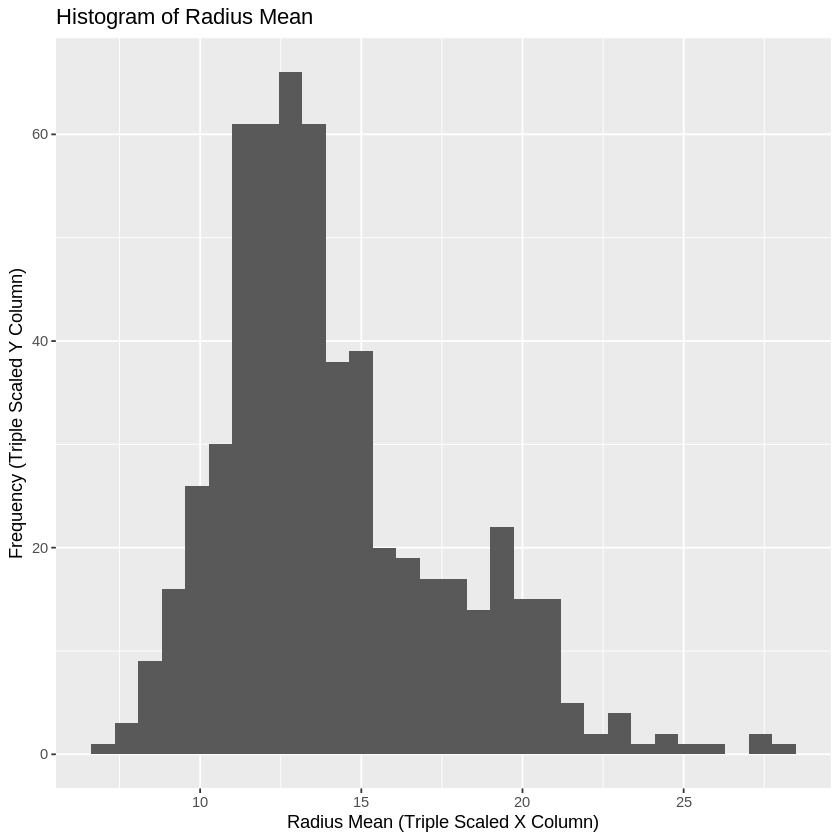

In [ ]:
# Histogram
ggplot(
  dl,
  aes(x = radius_mean)
) +
  geom_histogram(
    bins = 30
  ) +
  labs(
    title = "Histogram of Radius Mean",
    x = "Radius Mean (Triple Scaled X Column)",
    y = "Frequency (Triple Scaled Y Column)"
  )

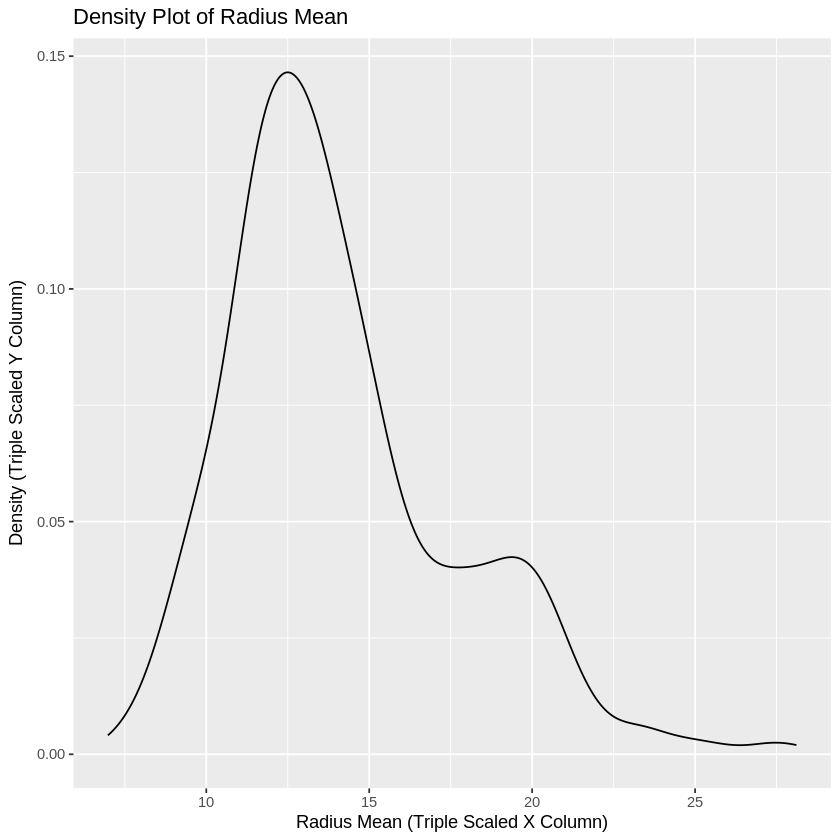

In [ ]:
# Density Plot (KDE)
ggplot(
  dl,
  aes(x = radius_mean)
) +
  geom_density() +
  labs(
    title = "Density Plot of Radius Mean",
    x = "Radius Mean (Triple Scaled X Column)",
    y = "Density (Triple Scaled Y Column)"
  )



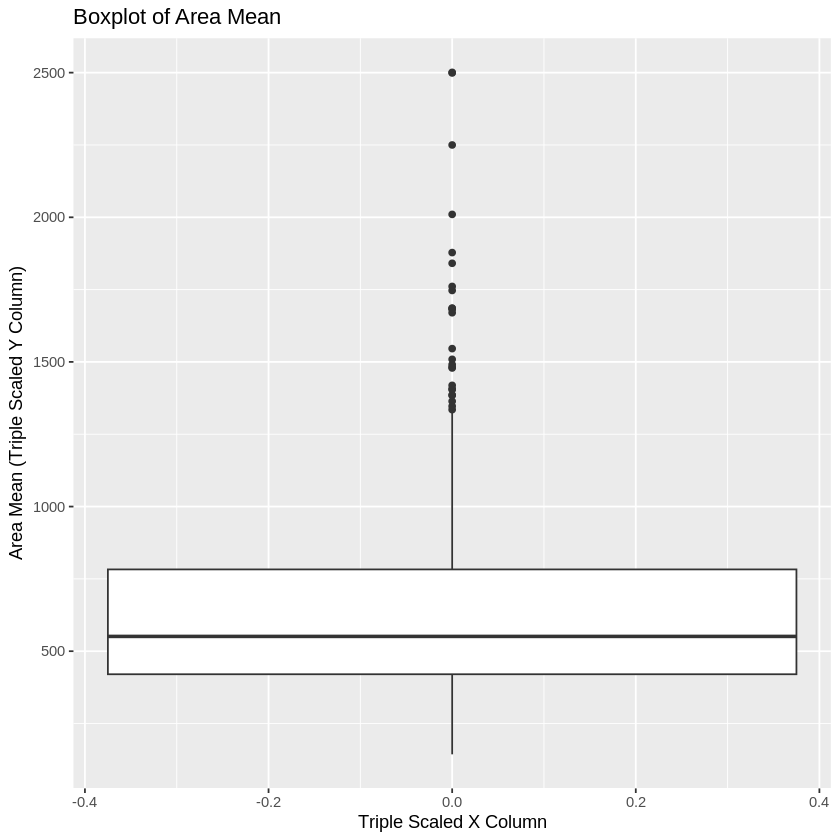

In [ ]:
# Boxplot
ggplot(
  dl,
  aes(y = area_mean)
) +
  geom_boxplot() +
  labs(
    title = "Boxplot of Area Mean",
    x = "Triple Scaled X Column",
    y = "Area Mean (Triple Scaled Y Column)"
  )

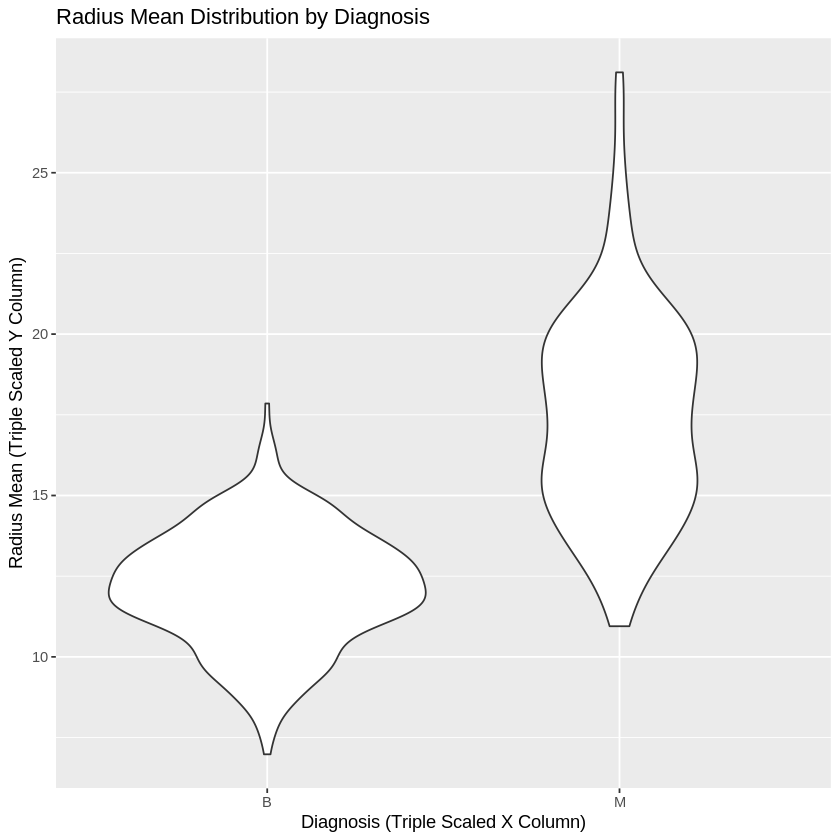

In [ ]:
# Violin Plot
ggplot(
  dl,
  aes(
    x = diagnosis,
    y = radius_mean
  )
) +
  geom_violin() +
  labs(
    title = "Radius Mean Distribution by Diagnosis",
    x = "Diagnosis (Triple Scaled X Column)",
    y = "Radius Mean (Triple Scaled Y Column)"
  )


`geom_smooth()` using formula = 'y ~ x'


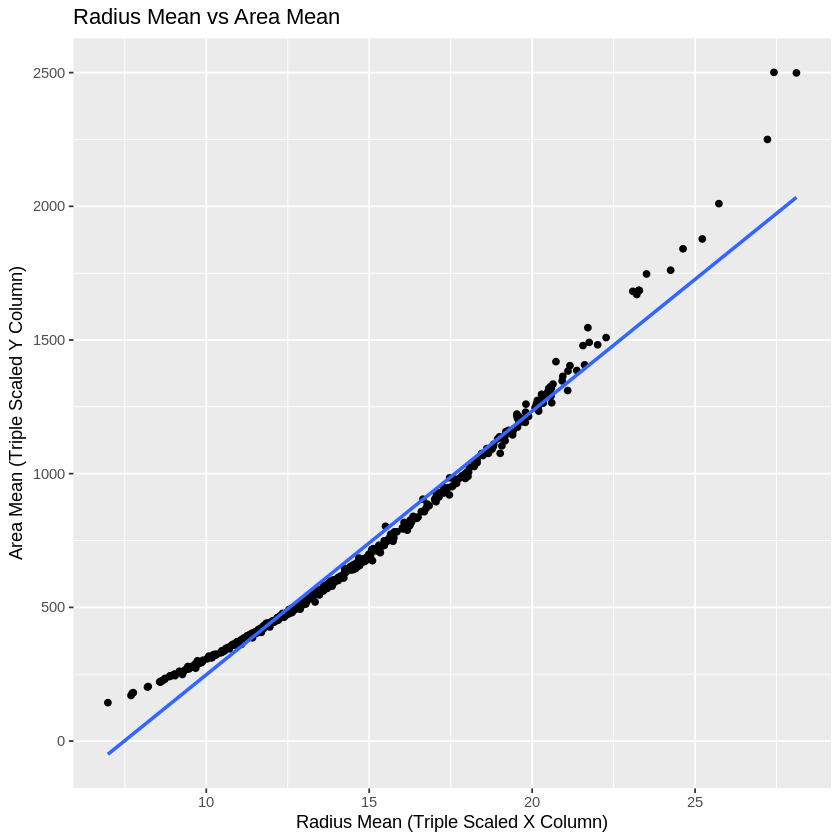

In [ ]:
# Scatter Plot with Trend Line
ggplot(
  dl,
  aes(
    x = radius_mean,
    y = area_mean
  )
) +
  geom_point() +
  geom_smooth(
    method = "lm",
    se = FALSE
  ) +
  labs(
    title = "Radius Mean vs Area Mean",
    x = "Radius Mean (Triple Scaled X Column)",
    y = "Area Mean (Triple Scaled Y Column)"
  )

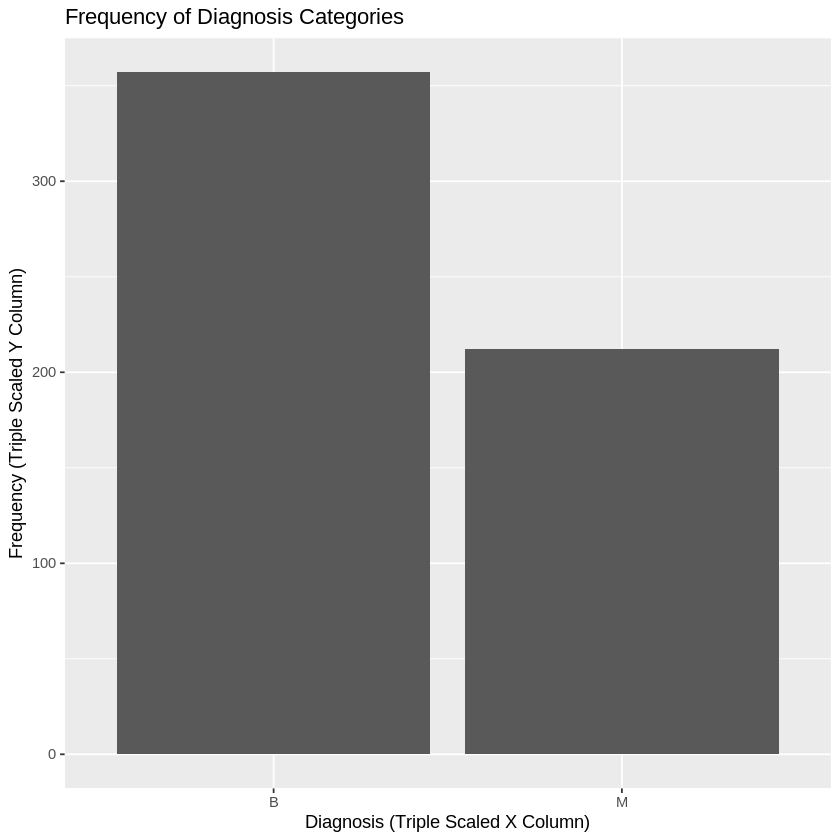

In [ ]:
# Bar Chart
ggplot(
  dl,
  aes(x = diagnosis)
) +
  geom_bar() +
  labs(
    title = "Frequency of Diagnosis Categories",
    x = "Diagnosis (Triple Scaled X Column)",
    y = "Frequency (Triple Scaled Y Column)"
  )

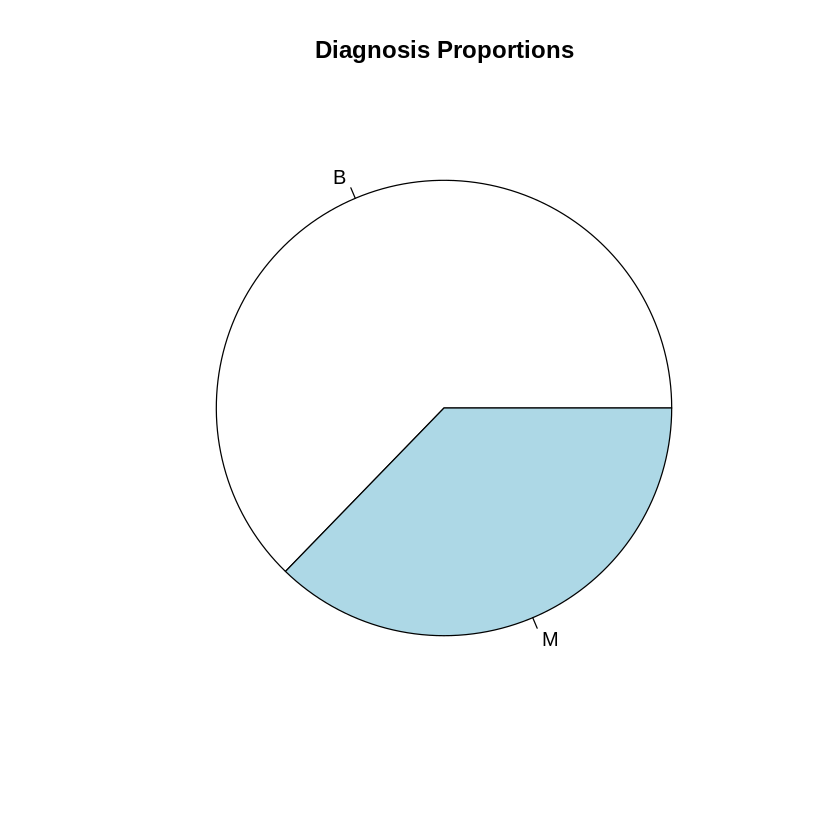

In [ ]:
# Pie Chart
diagnosis_count <- table(
  dl$diagnosis
)

pie(
  diagnosis_count,
  main = "Diagnosis Proportions"
)


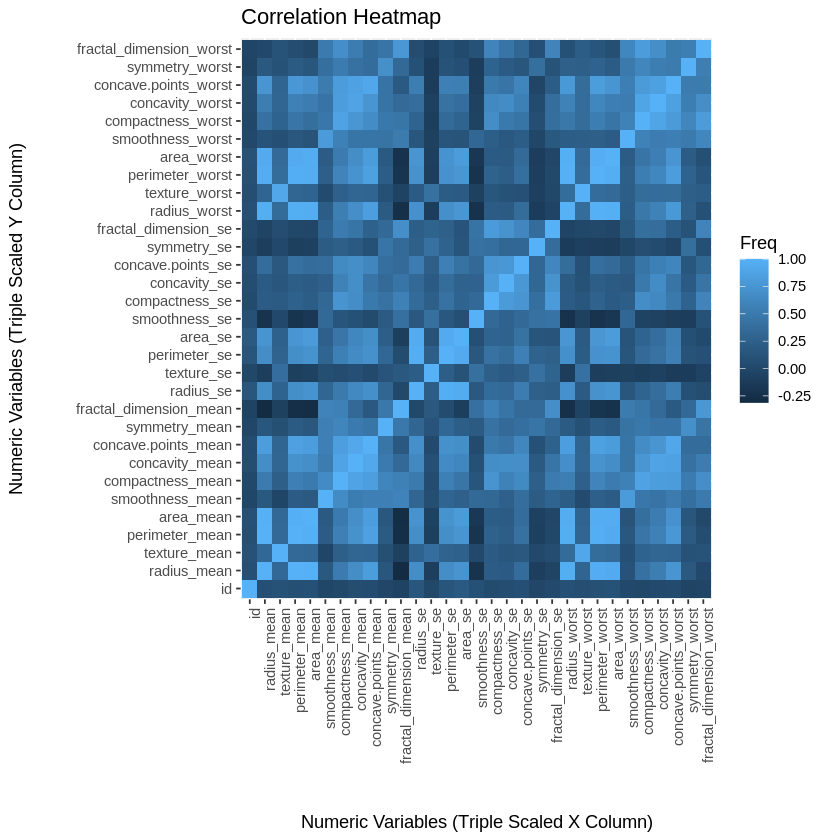

In [ ]:
# Correlation Heatmap
numeric_data <- dl[
  ,
  sapply(dl, is.numeric),
  drop = FALSE
]

correlation_matrix <- cor(
  numeric_data,
  use = "complete.obs"
)

correlation_data <- as.data.frame(
  as.table(correlation_matrix)
)

ggplot(
  correlation_data,
  aes(
    x = Var1,
    y = Var2,
    fill = Freq
  )
) +
  geom_tile() +
  labs(
    title = "Correlation Heatmap",
    x = "Numeric Variables (Triple Scaled X Column)",
    y = "Numeric Variables (Triple Scaled Y Column)"
  ) +
  theme(
    axis.text.x = element_text(
      angle = 90,
      hjust = 1
    )
  )


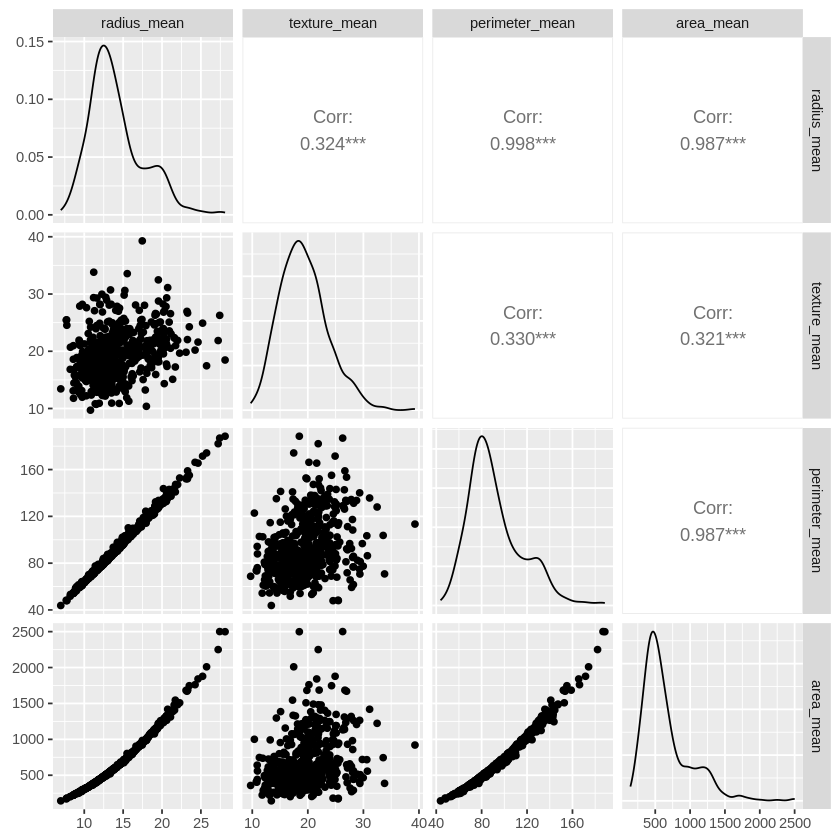

In [ ]:
# Pair Plot
if (!requireNamespace(
  "GGally",
  quietly = TRUE
)) {
  install.packages(
    "GGally",
  )
}

library(GGally)

ggpairs(
  dl[
    ,
    c(
      "radius_mean",
      "texture_mean",
      "perimeter_mean",
      "area_mean"
    )
  ]
)


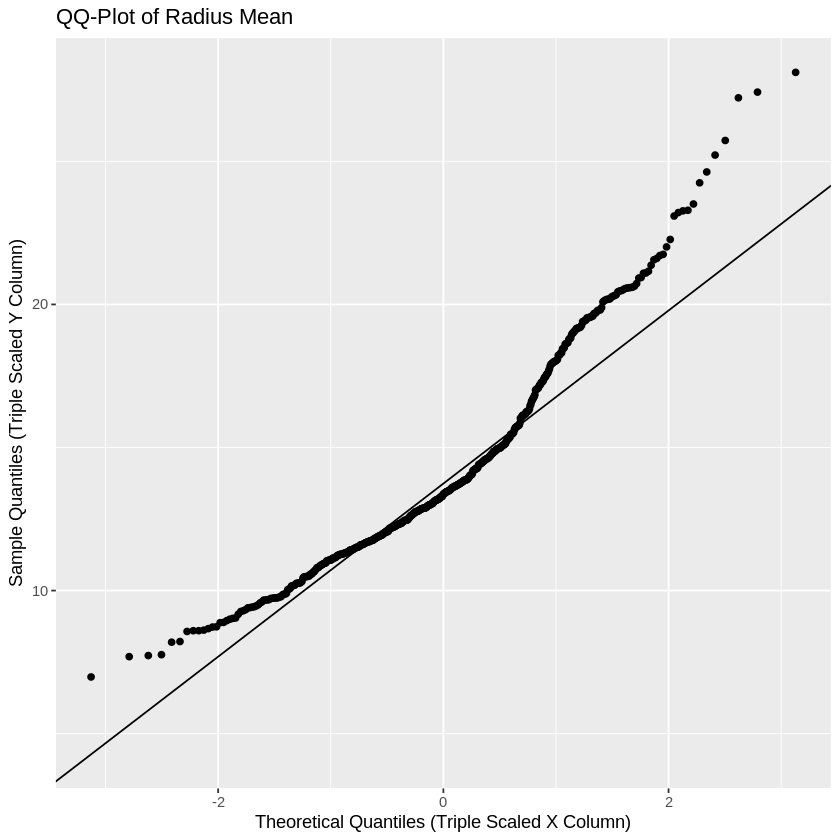

In [ ]:
# QQ-plot
ggplot(
  dl,
  aes(
    sample = radius_mean
  )
) +
  stat_qq() +
  stat_qq_line() +
  labs(
    title = "QQ-Plot of Radius Mean",
    x = "Theoretical Quantiles (Triple Scaled X Column)",
    y = "Sample Quantiles (Triple Scaled Y Column)"
  )


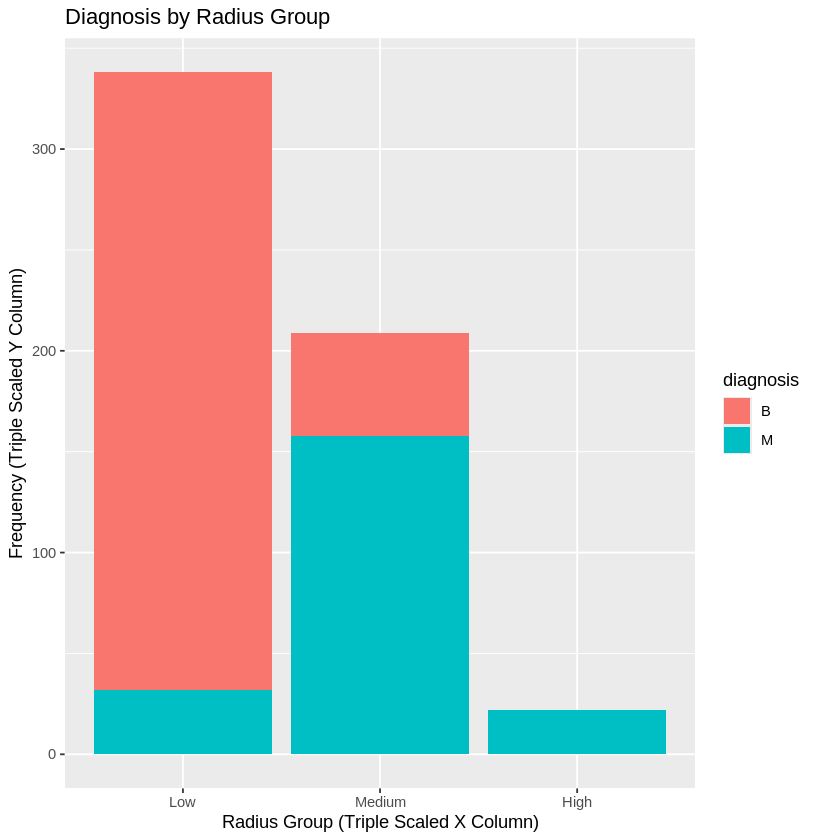

In [ ]:
# Stacked Bar Chart
dl$radius_group <- cut(
  dl$radius_mean,
  breaks = 3,
  labels = c(
    "Low",
    "Medium",
    "High"
  )
)

ggplot(
  dl,
  aes(
    x = radius_group,
    fill = diagnosis
  )
) +
  geom_bar() +
  labs(
    title = "Diagnosis by Radius Group",
    x = "Radius Group (Triple Scaled X Column)",
    y = "Frequency (Triple Scaled Y Column)"
  )

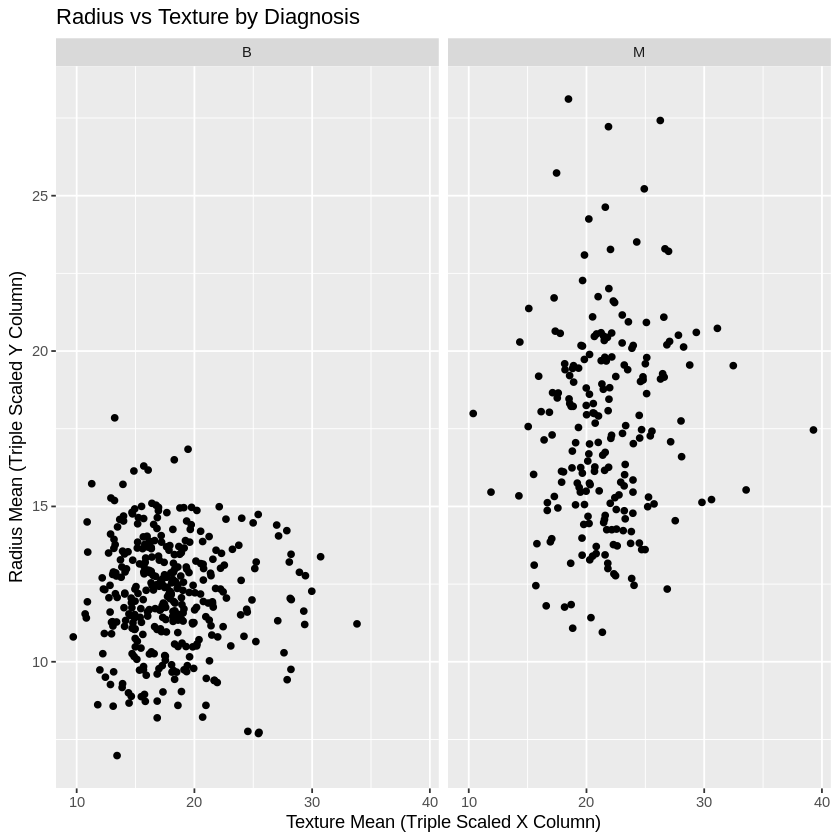

In [ ]:
# Facet Grid / Small Multiples
ggplot(
  dl,
  aes(
    x = texture_mean,
    y = radius_mean
  )
) +
  geom_point() +
  facet_wrap(
    ~ diagnosis
  ) +
  labs(
    title = "Radius vs Texture by Diagnosis",
    x = "Texture Mean (Triple Scaled X Column)",
    y = "Radius Mean (Triple Scaled Y Column)"
  )


Picking joint bandwidth of 0.731



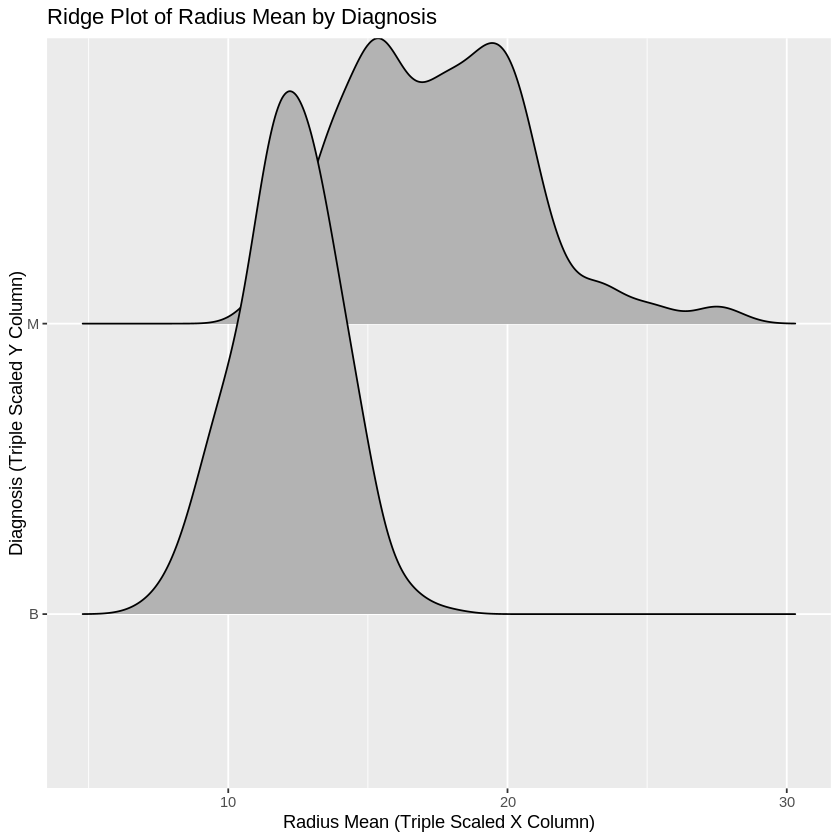

In [ ]:
# Ridge Plot
if (!requireNamespace(
  "ggridges",
  quietly = TRUE
)) {
  install.packages(
    "ggridges",
  )
}

library(ggridges)

ggplot(
  dl,
  aes(
    x = radius_mean,
    y = diagnosis
  )
) +
  geom_density_ridges() +
  labs(
    title = "Ridge Plot of Radius Mean by Diagnosis",
    x = "Radius Mean (Triple Scaled X Column)",
    y = "Diagnosis (Triple Scaled Y Column)"
  )


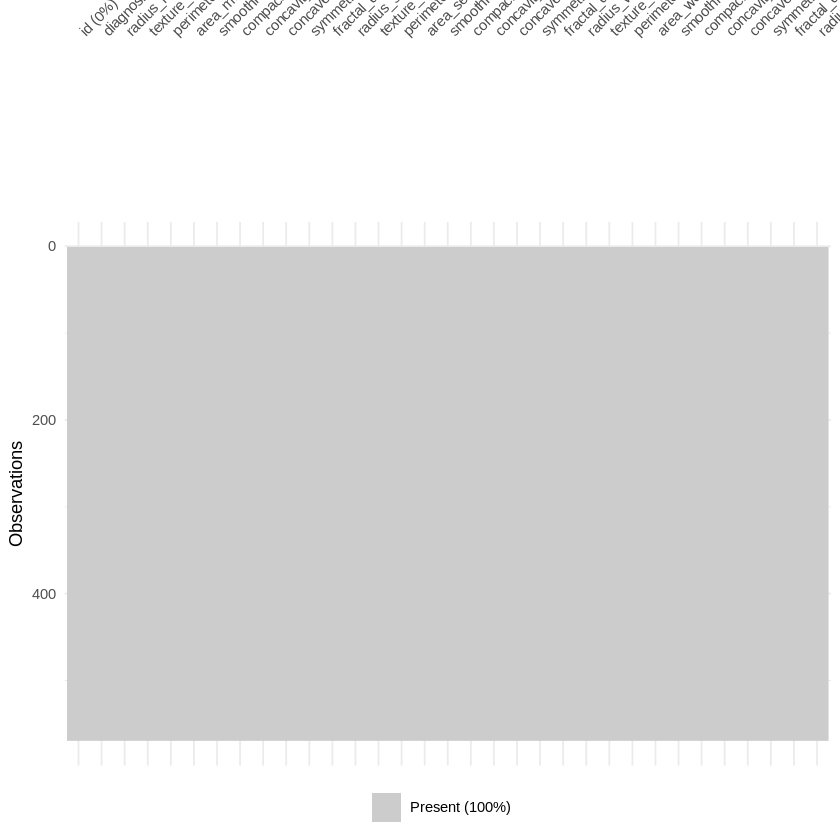

In [ ]:
# Missing-Value Pattern Plot
if (!requireNamespace(
  "naniar",
  quietly = TRUE
)) {
  install.packages(
    "naniar",
  )
}

library(naniar)

vis_miss(dl)

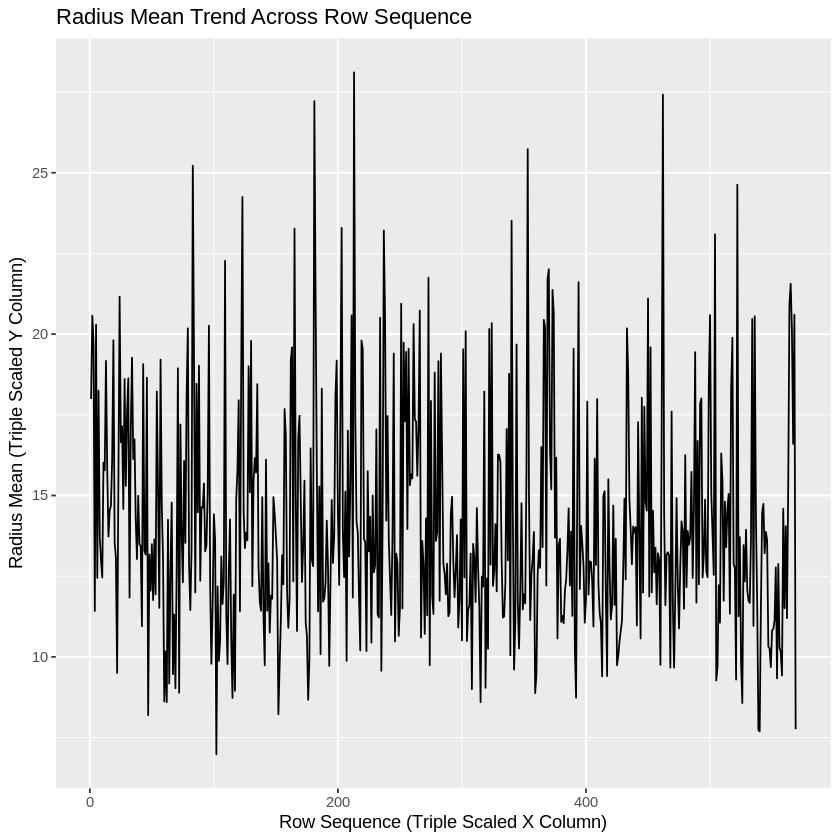

In [ ]:
# Line / Trend Plot
dl$row_number <- seq_len(
  nrow(dl)
)

ggplot(
  dl,
  aes(
    x = row_number,
    y = radius_mean
  )
) +
  geom_line() +
  labs(
    title = "Radius Mean Trend Across Row Sequence",
    x = "Row Sequence (Triple Scaled X Column)",
    y = "Radius Mean (Triple Scaled Y Column)"
  )


#6 Descriptive Statistics

In [ ]:
# Load required packages
if (!requireNamespace("e1071", quietly = TRUE)) {
  install.packages(
    "e1071",
  )
}

library(e1071)


Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element




In [ ]:
# Convert diagnosis to factor
dl$diagnosis <- as.factor(
  dl$diagnosis
)

In [ ]:
# Convert all selected columns to numeric
key_data[] <- lapply(
  key_data,
  function(x) as.numeric(as.character(x))
)

In [ ]:
# Mean
mean_values <- sapply(
  key_data,
  function(x) mean(x, na.rm = TRUE)
)
# Median
median_values <- sapply(
  key_data,
  function(x) median(x, na.rm = TRUE)
)
# Mode
get_mode <- function(x) {

  x <- x[!is.na(x)]

  unique_values <- unique(x)

  frequency <- tabulate(
    match(x, unique_values)
  )

  unique_values[
    which.max(frequency)
  ]
}

mode_values <- sapply(
  key_data,
  function(x) get_mode(x)
)
# Create table
central_tendency <- data.frame(
  Variable = key_variables,
  Mean = as.numeric(unlist(mean_values)),
  Median = as.numeric(unlist(median_values)),
  Mode = as.numeric(unlist(mode_values))
)

print(central_tendency)

                  Variable         Mean    Median      Mode
1              radius_mean 1.412729e+01 1.337e+01 1.234e+01
2             texture_mean 1.928965e+01 1.884e+01 1.570e+01
3           perimeter_mean 9.196903e+01 8.624e+01 8.261e+01
4                area_mean 6.548891e+02 5.511e+02 5.122e+02
5          smoothness_mean 9.636028e-02 9.587e-02 1.007e-01
6         compactness_mean 1.043410e-01 9.263e-02 1.206e-01
7           concavity_mean 8.879932e-02 6.154e-02 0.000e+00
8      concave.points_mean 4.891915e-02 3.350e-02 0.000e+00
9            symmetry_mean 1.811619e-01 1.792e-01 1.769e-01
10  fractal_dimension_mean 6.279761e-02 6.154e-02 5.667e-02
11               radius_se 4.051721e-01 3.242e-01 2.860e-01
12              texture_se 1.216853e+00 1.108e+00 1.150e+00
13            perimeter_se 2.866059e+00 2.287e+00 1.778e+00
14                 area_se 4.033708e+01 2.453e+01 1.697e+01
15           smoothness_se 7.040979e-03 6.380e-03 6.399e-03
16          compactness_se 2.547814e-02 

In [ ]:
# Quartiles and Percentiles
percentile_statistics <- data.frame(
  Variable = key_variables,

  P10 = sapply(
    key_data,
    quantile,
    probs = 0.10,
    na.rm = TRUE
  ),

  Q1_P25 = sapply(
    key_data,
    quantile,
    probs = 0.25,
    na.rm = TRUE
  ),

  Median_P50 = sapply(
    key_data,
    quantile,
    probs = 0.50,
    na.rm = TRUE
  ),

  Q3_P75 = sapply(
    key_data,
    quantile,
    probs = 0.75,
    na.rm = TRUE
  ),

  P90 = sapply(
    key_data,
    quantile,
    probs = 0.90,
    na.rm = TRUE
  ),

  P95 = sapply(
    key_data,
    quantile,
    probs = 0.95,
    na.rm = TRUE
  ),

  P99 = sapply(
    key_data,
    quantile,
    probs = 0.99,
    na.rm = TRUE
  )
)

print(percentile_statistics)

                                           Variable        P10    Q1_P25
radius_mean.10%                         radius_mean 1.0260e+01 1.170e+01
texture_mean.10%                       texture_mean 1.4078e+01 1.617e+01
perimeter_mean.10%                   perimeter_mean 6.5830e+01 7.517e+01
area_mean.10%                             area_mean 3.2160e+02 4.203e+02
smoothness_mean.10%                 smoothness_mean 7.9654e-02 8.637e-02
compactness_mean.10%               compactness_mean 4.9700e-02 6.492e-02
concavity_mean.10%                   concavity_mean 1.3686e-02 2.956e-02
concave.points_mean.10%         concave.points_mean 1.1158e-02 2.031e-02
symmetry_mean.10%                     symmetry_mean 1.4958e-01 1.619e-01
fractal_dimension_mean.10%   fractal_dimension_mean 5.5338e-02 5.770e-02
radius_se.10%                             radius_se 1.8308e-01 2.324e-01
texture_se.10%                           texture_se 6.4040e-01 8.339e-01
perimeter_se.10%                       perimeter_se

In [ ]:
# Skewness and Excess Kurtosis
shape_statistics <- data.frame(
  Variable = key_variables,

  Skewness = sapply(
    key_data,
    function(x) {
      e1071::skewness(
        x,
        na.rm = TRUE,
        type = 3
      )
    }
  ),

  Excess_Kurtosis = sapply(
    key_data,
    function(x) {
      e1071::kurtosis(
        x,
        na.rm = TRUE,
        type = 3
      )
    }
  )
)

print(shape_statistics)


                                       Variable  Skewness Excess_Kurtosis
radius_mean                         radius_mean 0.9374168       0.8141418
texture_mean                       texture_mean 0.6470241       0.7280071
perimeter_mean                   perimeter_mean 0.9854334       0.9392821
area_mean                             area_mean 1.6370654       3.5865488
smoothness_mean                 smoothness_mean 0.4539207       0.8244671
compactness_mean               compactness_mean 1.1838556       1.6088967
concavity_mean                   concavity_mean 1.3938008       1.9531357
concave.points_mean         concave.points_mean 1.1650124       1.0324689
symmetry_mean                     symmetry_mean 0.7217877       1.2511350
fractal_dimension_mean   fractal_dimension_mean 1.2976191       2.9480546
radius_se                             radius_se 3.0723468      17.4490950
texture_se                           texture_se 1.6377733       5.2626335
perimeter_se                       per

In [ ]:
#  DESCRIPTIVE STATISTICS BY DIAGNOSIS
grouped_statistics <- aggregate(
  key_data,
  by = list(
    Diagnosis = dl$diagnosis
  ),
  FUN = function(x) {
    c(
      Mean = mean(x, na.rm = TRUE),
      Median = median(x, na.rm = TRUE),
      SD = sd(x, na.rm = TRUE),
      IQR = IQR(x, na.rm = TRUE)
    )
  }
)

print(grouped_statistics)

  Diagnosis radius_mean.Mean radius_mean.Median radius_mean.SD radius_mean.IQR
1         B        12.146524          12.200000       1.780512        2.290000
2         M        17.462830          17.325000       3.203971        4.515000
  texture_mean.Mean texture_mean.Median texture_mean.SD texture_mean.IQR
1         17.914762           17.390000        3.995125         4.610000
2         21.604906           21.460000        3.779470         4.437500
  perimeter_mean.Mean perimeter_mean.Median perimeter_mean.SD
1            78.07541              78.18000          11.80744
2           115.36538             114.20000          21.85465
  perimeter_mean.IQR area_mean.Mean area_mean.Median area_mean.SD area_mean.IQR
1           15.23000       462.7902         458.4000     134.2871      172.9000
2           31.18000       978.3764         932.0000     367.9380      498.4500
  smoothness_mean.Mean smoothness_mean.Median smoothness_mean.SD
1           0.09247765             0.09076000        

In [ ]:
# GROUP-WISE
group_means <- aggregate(
  key_data,
  by = list(
    Diagnosis = dl$diagnosis
  ),
  FUN = mean,
  na.rm = TRUE
)

print(group_means)

  Diagnosis radius_mean texture_mean perimeter_mean area_mean smoothness_mean
1         B    12.14652     17.91476       78.07541  462.7902      0.09247765
2         M    17.46283     21.60491      115.36538  978.3764      0.10289849
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1       0.08008462     0.04605762          0.02571741      0.174186
2       0.14518778     0.16077472          0.08799000      0.192909
  fractal_dimension_mean radius_se texture_se perimeter_se  area_se
1             0.06286739 0.2840824   1.220380     2.000321 21.13515
2             0.06268009 0.6090825   1.210915     4.323929 72.67241
  smoothness_se compactness_se concavity_se concave.points_se symmetry_se
1   0.007195902     0.02143825   0.02599674       0.009857653  0.02058381
2   0.006780094     0.03228117   0.04182401       0.015060472  0.02047240
  fractal_dimension_se radius_worst texture_worst perimeter_worst area_worst
1          0.003636051     13.37980      23.51507        87

In [ ]:
# GROUP-WISE STANDARD DEVIATION
group_sd <- aggregate(
  key_data,
  by = list(
    Diagnosis = dl$diagnosis
  ),
  FUN = sd,
  na.rm = TRUE
)
print(group_sd)

  Diagnosis radius_mean texture_mean perimeter_mean area_mean smoothness_mean
1         B    1.780512     3.995125       11.80744  134.2871      0.01344608
2         M    3.203971     3.779470       21.85465  367.9380      0.01260824
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1       0.03374995     0.04344215          0.01590878    0.02480676
2       0.05398750     0.07501933          0.03437391    0.02763809
  fractal_dimension_mean radius_se texture_se perimeter_se   area_se
1            0.006747343 0.1125696  0.5891797    0.7711692  8.843472
2            0.007573315 0.3450386  0.4831781    2.5685457 61.355268
  smoothness_se compactness_se concavity_se concave.points_se symmetry_se
1    0.00306061     0.01635151   0.03291824       0.005708625 0.006998539
2    0.00289043     0.01838719   0.02160343       0.005517362 0.010064888
  fractal_dimension_se radius_worst texture_worst perimeter_worst area_worst
1          0.002938219     1.981368      5.493955       

In [ ]:
#  GROUP-WISE SKEWNESS
group_skewness <- aggregate(
  key_data,
  by = list(
    Diagnosis = dl$diagnosis
  ),
  FUN = function(x) {
    e1071::skewness(
      x,
      na.rm = TRUE,
      type = 3
    )
  }
)

print(group_skewness)

  Diagnosis radius_mean texture_mean perimeter_mean area_mean smoothness_mean
1         B -0.08309623    0.9731126    -0.06414149 0.3393946       0.6578830
2         M  0.49482197    0.6936181     0.59639717 1.1019019       0.4729837
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1        1.2022730      3.4441315           0.9172070     0.6534160
2        0.8249643      0.8889094           0.7286658     0.8005061
  fractal_dimension_mean radius_se texture_se perimeter_se  area_se
1              1.6368182  1.491310   1.640626     1.177777 1.632335
2              0.8821444  2.483863   1.514655     2.770496 4.283736
  smoothness_se compactness_se concavity_se concave.points_se symmetry_se
1      1.495843       2.193736     6.273956          2.129099    1.366258
2      3.902937       1.831731     1.601062          1.417714    2.484039
  fractal_dimension_se radius_worst texture_worst perimeter_worst area_worst
1             4.299069  -0.03132083     0.7157619     0.008

In [ ]:
# GROUP-WISE EXCESS KURTOSIS
group_kurtosis <- aggregate(
  key_data,
  by = list(
    Diagnosis = dl$diagnosis
  ),
  FUN = function(x) {
    e1071::kurtosis(
      x,
      na.rm = TRUE,
      type = 3
    )
  }
)

print(group_kurtosis)


  Diagnosis radius_mean texture_mean perimeter_mean area_mean smoothness_mean
1         B -0.04549322     1.162458    -0.04959215 0.2700233       1.7858270
2         M  0.30603512     2.245361     0.51580362 2.1746781       0.3617036
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1         2.208558      20.395767           0.9843514      1.247079
2         0.771152       1.058996           0.6501385      1.210065
  fractal_dimension_mean radius_se texture_se perimeter_se   area_se
1               4.363772  3.900224   5.302867     1.677894  5.209452
2               1.226867 11.655121   3.695226    13.419073 28.042085
  smoothness_se compactness_se concavity_se concave.points_se symmetry_se
1      2.969093       5.853832    57.862118         10.401347    3.242469
2     26.679038       5.397916     3.554139          3.557451    7.761428
  fractal_dimension_se radius_worst texture_worst perimeter_worst area_worst
1            27.175474   -0.1933538     0.4056503      -

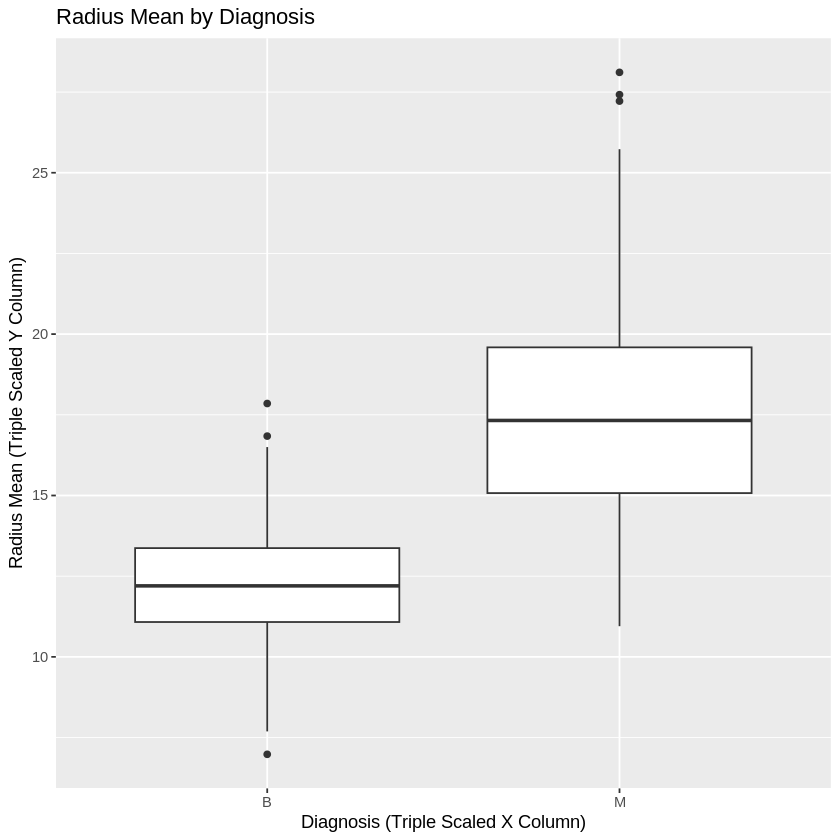

In [ ]:
# VISUALIZATION
ggplot(
  dl,
  aes(
    x = diagnosis,
    y = radius_mean
  )
) +
  geom_boxplot() +
  labs(
    title = "Radius Mean by Diagnosis",
    x = "Diagnosis (Triple Scaled X Column)",
    y = "Radius Mean (Triple Scaled Y Column)"
  )


#7 Outlier Detection

In [ ]:
# Select numeric variables
numeric_data <- dl[
  ,
  sapply(dl, is.numeric),
  drop = FALSE
]

In [ ]:
# IQR METHOD
# Outlier rule:
# Below Q1 - 1.5 * IQR
# Above Q3 + 1.5 * IQR

iqr_outlier_count <- sapply(
  numeric_data,
  function(x) {

    Q1 <- quantile(
      x,
      0.25,
      na.rm = TRUE
    )

    Q3 <- quantile(
      x,
      0.75,
      na.rm = TRUE
    )

    IQR_value <- IQR(
      x,
      na.rm = TRUE
    )

    lower_limit <- Q1 - 1.5 * IQR_value
    upper_limit <- Q3 + 1.5 * IQR_value

    sum(
      x < lower_limit |
      x > upper_limit,
      na.rm = TRUE
    )
  }
)

print(iqr_outlier_count)



                     id             radius_mean            texture_mean 
                     81                      14                       7 
         perimeter_mean               area_mean         smoothness_mean 
                     13                      25                       6 
       compactness_mean          concavity_mean     concave.points_mean 
                     16                      18                      10 
          symmetry_mean  fractal_dimension_mean               radius_se 
                     15                      15                      38 
             texture_se            perimeter_se                 area_se 
                     20                      38                      65 
          smoothness_se          compactness_se            concavity_se 
                     30                      28                      22 
      concave.points_se             symmetry_se    fractal_dimension_se 
                     19                      27    

In [ ]:
# RANGE CHECK
range_check <- data.frame(
  Variable = names(numeric_data),
  Minimum = sapply(
    numeric_data,
    min,
    na.rm = TRUE
  ),
  Maximum = sapply(
    numeric_data,
    max,
    na.rm = TRUE
  )
)

print(range_check)

                                       Variable   Minimum      Maximum
id                                           id 8.670e+03 9.113205e+08
radius_mean                         radius_mean 6.981e+00 2.811000e+01
texture_mean                       texture_mean 9.710e+00 3.928000e+01
perimeter_mean                   perimeter_mean 4.379e+01 1.885000e+02
area_mean                             area_mean 1.435e+02 2.501000e+03
smoothness_mean                 smoothness_mean 5.263e-02 1.634000e-01
compactness_mean               compactness_mean 1.938e-02 3.454000e-01
concavity_mean                   concavity_mean 0.000e+00 4.268000e-01
concave.points_mean         concave.points_mean 0.000e+00 2.012000e-01
symmetry_mean                     symmetry_mean 1.060e-01 3.040000e-01
fractal_dimension_mean   fractal_dimension_mean 4.996e-02 9.744000e-02
radius_se                             radius_se 1.115e-01 2.873000e+00
texture_se                           texture_se 3.602e-01 4.885000e+00
perime

In [ ]:
# Detect negative values
negative_value_count <- sapply(
  numeric_data,
  function(x) {
    sum(x < 0, na.rm = TRUE)
  }
)

print(negative_value_count)

                     id             radius_mean            texture_mean 
                      0                       0                       0 
         perimeter_mean               area_mean         smoothness_mean 
                      0                       0                       0 
       compactness_mean          concavity_mean     concave.points_mean 
                      0                       0                       0 
          symmetry_mean  fractal_dimension_mean               radius_se 
                      0                       0                       0 
             texture_se            perimeter_se                 area_se 
                      0                       0                       0 
          smoothness_se          compactness_se            concavity_se 
                      0                       0                       0 
      concave.points_se             symmetry_se    fractal_dimension_se 
                      0                       0    

In [ ]:
# Z-SCORE METHOD
z_score_outlier_count <- sapply(
  numeric_data,
  function(x) {

    z_scores <- scale(x)

    sum(
      abs(z_scores) > 3,
      na.rm = TRUE
    )
  }
)

print(z_score_outlier_count)

                     id             radius_mean            texture_mean 
                     11                       5                       4 
         perimeter_mean               area_mean         smoothness_mean 
                      7                       8                       5 
       compactness_mean          concavity_mean     concave.points_mean 
                      9                       9                       6 
          symmetry_mean  fractal_dimension_mean               radius_se 
                      5                       7                       7 
             texture_se            perimeter_se                 area_se 
                      9                       8                       6 
          smoothness_se          compactness_se            concavity_se 
                      7                      12                       6 
      concave.points_se             symmetry_se    fractal_dimension_se 
                      6                      11    

In [ ]:
# MODIFIED Z-SCORE
modified_z_outlier_count <- sapply(
  numeric_data,
  function(x) {

    median_value <- median(
      x,
      na.rm = TRUE
    )

    MAD_value <- mad(
      x,
      na.rm = TRUE
    )

    # Avoid division by zero
    if (MAD_value == 0) {
      return(0)
    }

    modified_z <- 0.6745 *
      (x - median_value) /
      MAD_value

    sum(
      abs(modified_z) > 3.5,
      na.rm = TRUE
    )
  }
)

print(modified_z_outlier_count)

                     id             radius_mean            texture_mean 
                    225                       1                       0 
         perimeter_mean               area_mean         smoothness_mean 
                      2                       8                       0 
       compactness_mean          concavity_mean     concave.points_mean 
                      1                       4                       2 
          symmetry_mean  fractal_dimension_mean               radius_se 
                      0                       3                      13 
             texture_se            perimeter_se                 area_se 
                      4                      14                      51 
          smoothness_se          compactness_se            concavity_se 
                      5                       7                       6 
      concave.points_se             symmetry_se    fractal_dimension_se 
                      3                       9    

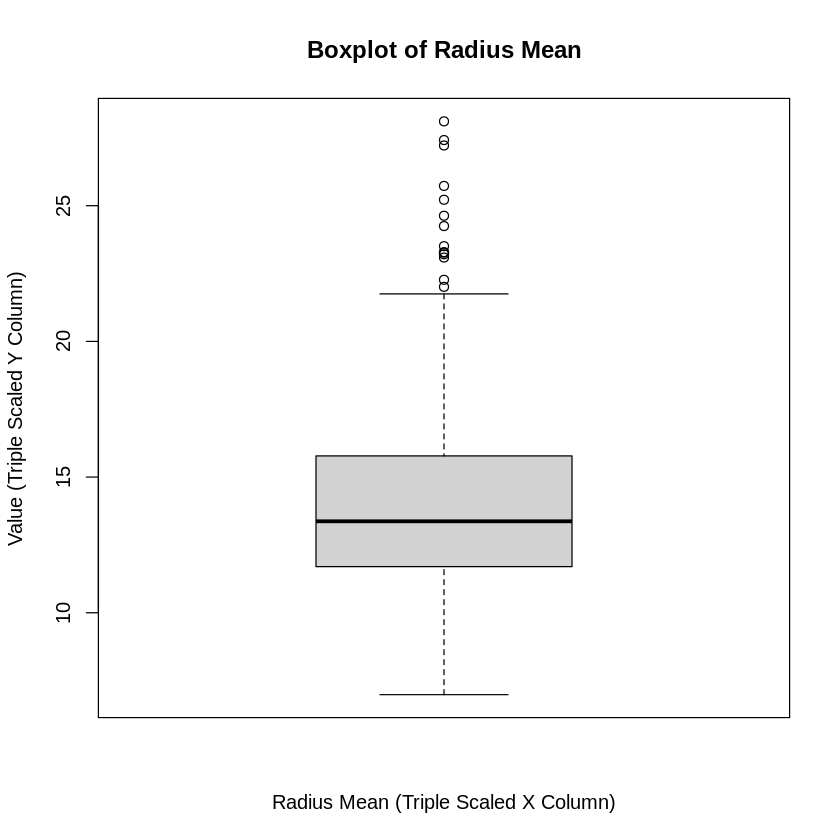

In [ ]:
# VISUAL INSPECTION
boxplot(
  dl$radius_mean,
  main = "Boxplot of Radius Mean",
  xlab = "Radius Mean (Triple Scaled X Column)",
  ylab = "Value (Triple Scaled Y Column)"
)

In [ ]:
# OUTLIER SUMMARY
outlier_summary <- data.frame(
  Variable = names(numeric_data),
  IQR_Outliers = iqr_outlier_count,
  ZScore_Outliers = z_score_outlier_count,
  Modified_Z_Outliers = modified_z_outlier_count
)

print(outlier_summary)


                                       Variable IQR_Outliers ZScore_Outliers
id                                           id           81              11
radius_mean                         radius_mean           14               5
texture_mean                       texture_mean            7               4
perimeter_mean                   perimeter_mean           13               7
area_mean                             area_mean           25               8
smoothness_mean                 smoothness_mean            6               5
compactness_mean               compactness_mean           16               9
concavity_mean                   concavity_mean           18               9
concave.points_mean         concave.points_mean           10               6
symmetry_mean                     symmetry_mean           15               5
fractal_dimension_mean   fractal_dimension_mean           15               7
radius_se                             radius_se           38               7

#8 Checking the Distribution

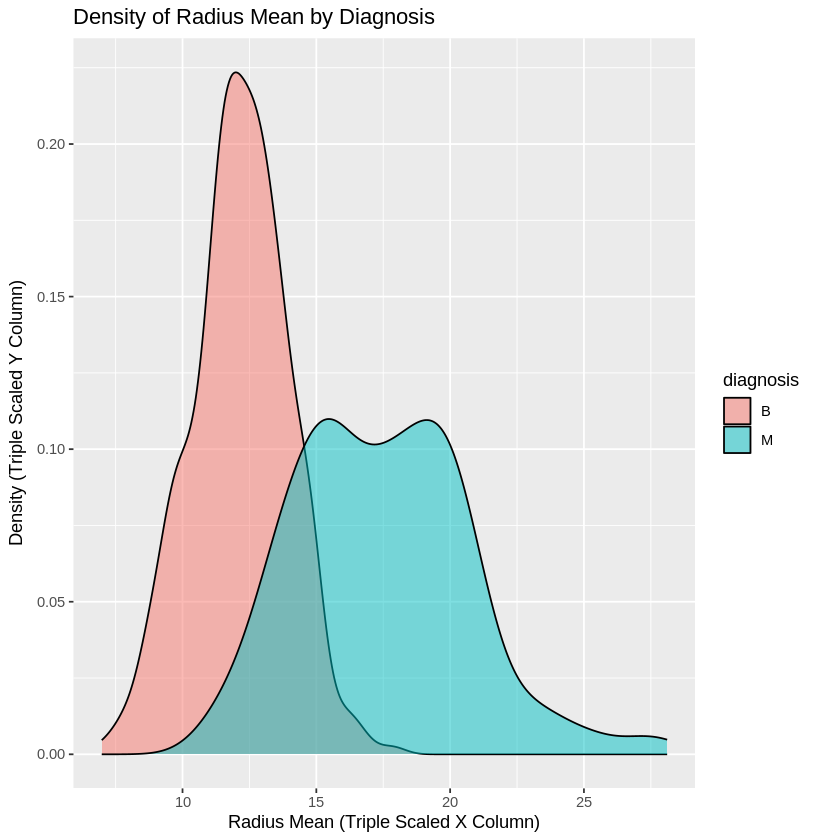

In [ ]:
# 1. DENSITY / KDE PLOT
ggplot(
  dl,
  aes(
    x = radius_mean,
    fill = diagnosis
  )
) +
  geom_density(
    alpha = 0.5
  ) +
  labs(
    title = "Density of Radius Mean by Diagnosis",
    x = "Radius Mean (Triple Scaled X Column)",
    y = "Density (Triple Scaled Y Column)"
  )

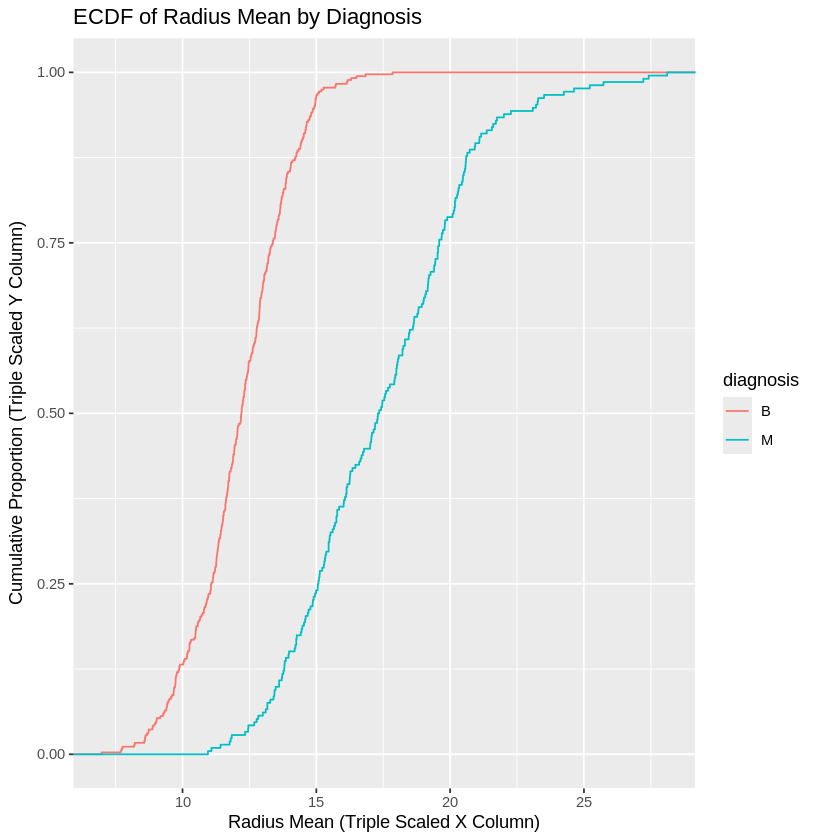

In [ ]:
# 2. ECDF PLOT
ggplot(
  dl,
  aes(
    x = radius_mean,
    color = diagnosis
  )
) +
  stat_ecdf() +
  labs(
    title = "ECDF of Radius Mean by Diagnosis",
    x = "Radius Mean (Triple Scaled X Column)",
    y = "Cumulative Proportion (Triple Scaled Y Column)"
  )

In [ ]:
# 3. SHAPIRO-WILK NORMALITY TEST
set.seed(123)

radius_sample <- sample(
  dl$radius_mean,
  size = min(
    5000,
    length(dl$radius_mean)
  )
)

shapiro_result <- shapiro.test(
  radius_sample
)

print(shapiro_result)



	Shapiro-Wilk normality test

data:  radius_sample
W = 0.94107, p-value = 3.106e-14



In [ ]:
# SHAPIRO-WILK TEST BY DIAGNOSIS
shapiro_by_group <- by(
  dl$radius_mean,
  dl$diagnosis,
  function(x) {

    x <- na.omit(x)

    # Use maximum 5000 observations
    if (length(x) > 5000) {
      set.seed(123)
      x <- sample(x, 5000)
    }

    shapiro.test(x)
  }
)

print(shapiro_by_group)


dl$diagnosis: B

	Shapiro-Wilk normality test

data:  x
W = 0.99665, p-value = 0.668

------------------------------------------------------------ 
dl$diagnosis: M

	Shapiro-Wilk normality test

data:  x
W = 0.97766, p-value = 0.001895



# 9. Statistical Hypothesis Testing

In [ ]:
# 9.1 ASSUMPTION CHECKS
# Normality: Shapiro-Wilk Test Per Group
benign_radius <- dl$radius_mean[
  dl$diagnosis == "B"
]

malignant_radius <- dl$radius_mean[
  dl$diagnosis == "M"
]

# Shapiro-Wilk test for Benign group
shapiro_benign <- shapiro.test(
  benign_radius
)

print(shapiro_benign)

# Shapiro-Wilk test for Malignant group
shapiro_malignant <- shapiro.test(
  malignant_radius
)

print(shapiro_malignant)

# Equal Variance: Levene's Test

if (!requireNamespace(
  "car",
  quietly = TRUE
)) {
  install.packages(
    "car",
  )
}

library(car)

levene_result <- leveneTest(
  radius_mean ~ diagnosis,
  data = dl
)

print(levene_result)



	Shapiro-Wilk normality test

data:  benign_radius
W = 0.99665, p-value = 0.668


	Shapiro-Wilk normality test

data:  malignant_radius
W = 0.97766, p-value = 0.001895



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:psych’:

    logit




Levene's Test for Homogeneity of Variance (center = median)
       Df F value    Pr(>F)    
group   1  90.477 < 2.2e-16 ***
      567                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [ ]:
# 9.2 COMPARING TWO GROUPS
# Independent Samples Welch's t-test

t_test_result <- t.test(
  radius_mean ~ diagnosis,
  data = dl,
  var.equal = FALSE
)

print(t_test_result)
# Cohen's d Effect Size

if (!requireNamespace(
  "effsize",
  quietly = TRUE
)) {
  install.packages(
    "effsize",
  )
}

library(effsize)

cohen_d_result <- cohen.d(
  radius_mean ~ diagnosis,
  data = dl
)

print(cohen_d_result)




	Welch Two Sample t-test

data:  radius_mean by diagnosis
t = -22.209, df = 289.71, p-value < 2.2e-16
alternative hypothesis: true difference in means between group B and group M is not equal to 0
95 percent confidence interval:
 -5.787448 -4.845165
sample estimates:
mean in group B mean in group M 
       12.14652        17.46283 



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘effsize’


The following object is masked from ‘package:psych’:

    cohen.d





Cohen's d

d estimate: -2.205463 (large)
95 percent confidence interval:
    lower     upper 
-2.418756 -1.992171 



In [ ]:
# 9.3 THREE OR MORE GROUPS
# One-Way ANOVA

dl$radius_group <- cut(
  dl$radius_mean,
  breaks = 3,
  labels = c(
    "Low",
    "Medium",
    "High"
  )
)

anova_result <- aov(
  texture_mean ~ radius_group,
  data = dl
)

summary(anova_result)

# Eta Squared Effect Size

if (!requireNamespace(
  "effectsize",
  quietly = TRUE
)) {
  install.packages(
    "effectsize",
  )
}

library(effectsize)

eta_squared_result <- eta_squared(
  anova_result
)

print(eta_squared_result)

# Two-Way ANOVA


dl$texture_group <- cut(
  dl$texture_mean,
  breaks = 3,
  labels = c(
    "Low",
    "Medium",
    "High"
  )
)

two_way_anova <- aov(
  area_mean ~ radius_group *
    texture_group,
  data = dl
)

summary(two_way_anova)

# ANCOVA

ancova_result <- aov(
  area_mean ~ diagnosis + texture_mean,
  data = dl
)

summary(ancova_result)

# MANOVA


manova_result <- manova(
  cbind(
    radius_mean,
    texture_mean,
    perimeter_mean
  ) ~ diagnosis,
  data = dl
)

summary(
  manova_result,
  test = "Wilks"
)

              Df Sum Sq Mean Sq F value   Pr(>F)    
radius_group   2    973   486.4   28.87 1.15e-12 ***
Residuals    566   9535    16.8                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bayestestR’, ‘insight’, ‘parameters’, ‘performance’, ‘datawizard’



Attaching package: ‘effectsize’


The following object is masked from ‘package:psych’:

    phi


For one-way between subjects designs, partial eta squared is equivalent
  to eta squared. Returning eta squared.



# Effect Size for ANOVA

Parameter    | Eta2 |       95% CI
----------------------------------
radius_group | 0.09 | [0.06, 1.00]

- One-sided CIs: upper bound fixed at [1.00].

                            Df   Sum Sq  Mean Sq F value  Pr(>F)    
radius_group                 2 53314132 26657066 907.074 < 2e-16 ***
texture_group                2   193965    96983   3.300 0.03760 *  
radius_group:texture_group   3   348382   116127   3.952 0.00832 ** 
Residuals                  561 16486660    29388                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

              Df   Sum Sq  Mean Sq F value Pr(>F)    
diagnosis      1 35358547 35358547 573.044 <2e-16 ***
texture_mean   1    60710    60710   0.984  0.322    
Residuals    566 34923882    61703                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

           Df   Wilks approx F num Df den Df    Pr(>F)    
diagnosis   1 0.39217    291.9      3    565 < 2.2e-16 ***
Residuals 567                                             
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [ ]:
# 9.4 CATEGORICAL VARIABLES AND PROPORTIONS
# Chi-Square Goodness-of-Fit Test

diagnosis_table <- table(
  dl$diagnosis
)

goodness_of_fit <- chisq.test(
  diagnosis_table,
  p = c(
    0.5,
    0.5
  )
)

print(goodness_of_fit)

# Chi-Square Test of Independence


diagnosis_radius_table <- table(
  dl$diagnosis,
  dl$radius_group
)

print(diagnosis_radius_table)


chi_independence <- chisq.test(
  diagnosis_radius_table
)

print(chi_independence)

# Cramer's V

if (!requireNamespace(
  "vcd",
  quietly = TRUE
)) {
  install.packages(
    "vcd",
  )
}

library(vcd)

cramers_v_result <- assocstats(
  diagnosis_radius_table
)

print(cramers_v_result)

# Two-Proportion Test

high_radius <- dl$radius_group == "High"

malignant_high <- sum(
  dl$diagnosis[high_radius] == "M"
)

total_high <- sum(
  high_radius
)

low_radius <- dl$radius_group == "Low"

malignant_low <- sum(
  dl$diagnosis[low_radius] == "M"
)

total_low <- sum(
  low_radius
)

prop_test_result <- prop.test(
  x = c(
    malignant_high,
    malignant_low
  ),
  n = c(
    total_high,
    total_low
  )
)

print(prop_test_result)



	Chi-squared test for given probabilities

data:  diagnosis_table
X-squared = 36.951, df = 1, p-value = 1.211e-09

   
    Low Medium High
  B 306     51    0
  M  32    158   22

	Pearson's Chi-squared test

data:  diagnosis_radius_table
X-squared = 280.14, df = 2, p-value < 2.2e-16



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: grid


Attaching package: ‘vcd’


The following object is masked from ‘package:effectsize’:

    oddsratio




                    X^2 df P(> X^2)
Likelihood Ratio 307.43  2        0
Pearson          280.14  2        0

Phi-Coefficient   : NA 
Contingency Coeff.: 0.574 
Cramer's V        : 0.702 


Warning message in prop.test(x = c(malignant_high, malignant_low), n = c(total_high, :
“Chi-squared approximation may be incorrect”



	2-sample test for equality of proportions with continuity correction

data:  c(malignant_high, malignant_low) out of c(total_high, total_low)
X-squared = 125.78, df = 1, p-value < 2.2e-16
alternative hypothesis: two.sided
95 percent confidence interval:
 0.8499078 0.9607431
sample estimates:
    prop 1     prop 2 
1.00000000 0.09467456 



In [ ]:
# 9.5 NON-PARAMETRIC ALTERNATIVES
# Wilcoxon Rank-Sum / Mann-Whitney

wilcoxon_result <- wilcox.test(
  radius_mean ~ diagnosis,
  data = dl
)

print(wilcoxon_result)

# Kruskal-Wallis Test

kruskal_result <- kruskal.test(
  texture_mean ~ radius_group,
  data = dl
)

print(kruskal_result)

# Dunn's Post-Hoc Test

if (!requireNamespace(
  "rstatix",
  quietly = TRUE
)) {
  install.packages(
    "rstatix",
  )
}

library(rstatix)

dunn_result <- dl %>%
  dunn_test(
    texture_mean ~ radius_group,
    p.adjust.method = "bonferroni"
  )

print(dunn_result)


	Wilcoxon rank sum test with continuity correction

data:  radius_mean by diagnosis
W = 4729, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


	Kruskal-Wallis rank sum test

data:  texture_mean by radius_group
Kruskal-Wallis chi-squared = 62.424, df = 2, p-value = 2.785e-14



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘corrplot’



Attaching package: ‘rstatix’


The following object is masked _by_ ‘.GlobalEnv’:

    get_mode


The following objects are masked from ‘package:effectsize’:

    cohens_d, eta_squared, omega_squared


The following object is masked from ‘package:stats’:

    filter




# A tibble: 3 × 9
  .y.         group1 group2    n1    n2 statistic        p    p.adj p.adj.signif
* <chr>       <chr>  <chr>  <int> <int>     <dbl>    <dbl>    <dbl> <chr>       
1 texture_me… Low    Medium   338   209      7.18 6.88e-13 2.07e-12 ****        
2 texture_me… Low    High     338    22      4.35 1.35e- 5 4.04e- 5 ****        
3 texture_me… Medium High     209    22      1.45 1.46e- 1 4.39e- 1 ns          


# 10. Sampling Techniques

In [ ]:
# 1. SIMPLE RANDOM SAMPLING
sample_size <- 100

simple_random_sample <- dl[
  sample(
    1:nrow(dl),
    size = sample_size,
    replace = FALSE
  ),
  ,
  drop = FALSE
]

print(simple_random_sample)

          id diagnosis radius_mean texture_mean perimeter_mean area_mean
71    859575         M      18.940        21.31         123.60    1130.0
81    861103         B      11.450        20.97          73.81     401.5
437   908916         B      12.870        19.54          82.67     509.2
567   926954         M      16.600        28.08         108.30     858.1
270  8910720         B      10.710        20.39          69.50     344.9
412   905520         B      11.040        16.83          70.92     373.2
137   868223         B      11.710        16.67          74.72     423.6
46    857010         M      18.650        17.60         123.70    1076.0
64    859196         B       9.173        13.86          59.20     260.9
531    91858         B      11.750        17.56          75.89     422.9
229 88147202         B      12.620        23.97          81.35     496.4
129   866458         B      15.100        16.39          99.58     674.5
220 88119002         M      19.530        32.47    

In [ ]:
# 2. SYSTEMATIC SAMPLING

k <- 5

systematic_sample <- dl[
  seq(
    from = 1,
    to = nrow(dl),
    by = k
  ),
  ,
  drop = FALSE
]

print(systematic_sample)

           id diagnosis radius_mean texture_mean perimeter_mean area_mean
1      842302         M      17.990        10.38         122.80    1001.0
6      843786         M      12.450        15.70          82.57     477.1
11     845636         M      16.020        23.24         102.70     797.8
16   84799002         M      14.540        27.54          96.73     658.8
21    8510653         B      13.080        15.71          85.63     520.0
26     852631         M      17.140        16.40         116.00     912.7
31     853401         M      18.630        25.11         124.80    1088.0
36     854253         M      16.740        21.59         110.10     869.5
41     855167         M      13.440        21.58          86.18     563.0
46     857010         M      18.650        17.60         123.70    1076.0
51     857343         B      11.760        21.60          74.72     427.9
56   85759902         B      11.520        18.75          73.34     409.0
61     858970         B      10.170   

In [ ]:
# 3. STRATIFIED SAMPLING
stratified_sample <- do.call(
  rbind,
  lapply(
    levels(dl$diagnosis),
    function(group) {

      group_data <- dl[
        dl$diagnosis == group,
        ,
        drop = FALSE
      ]

      sample_n <- min(
        50,
        nrow(group_data)
      )

      group_data[
        sample(
          1:nrow(group_data),
          size = sample_n,
          replace = FALSE
        ),
        ,
        drop = FALSE
      ]
    }
  )
)

print(stratified_sample)

print(
  table(
    stratified_sample$diagnosis
  )
)

           id diagnosis radius_mean texture_mean perimeter_mean area_mean
425    907145         B       9.742        19.12          61.93     289.7
221   8812816         B      13.650        13.16          87.88     568.9
320    894335         B      12.430        17.00          78.60     477.3
341     89813         B      14.420        16.54          94.15     641.2
38     854941         B      13.030        18.42          82.61     523.8
530    918465         B      12.070        13.44          77.83     445.2
509    915452         B      16.300        15.70         104.70     819.8
121    865137         B      11.410        10.82          73.34     403.3
282   8912055         B      11.740        14.02          74.24     427.3
423    906616         B      11.610        16.02          75.46     408.2
535    919537         B      10.960        17.62          70.79     365.6
516    916221         B      11.340        18.61          72.76     391.2
427    907409         B      10.480   

In [ ]:
# 4. CLUSTER SAMPLING

dl$cluster <- rep(
  1:10,
  length.out = nrow(dl)
)

selected_clusters <- sample(
  unique(dl$cluster),
  size = 3,
  replace = FALSE
)

cluster_sample <- dl[
  dl$cluster %in% selected_clusters,
  ,
  drop = FALSE
]

print(cluster_sample)

           id diagnosis radius_mean texture_mean perimeter_mean area_mean
2      842517         M      20.570        17.77         132.90    1326.0
3    84300903         M      19.690        21.25         130.00    1203.0
9      844981         M      13.000        21.82          87.50     519.8
12   84610002         M      15.780        17.89         103.60     781.0
13     846226         M      19.170        24.80         132.40    1123.0
19     849014         M      19.810        22.15         130.00    1260.0
22    8510824         B       9.504        12.44          60.34     273.9
23    8511133         M      15.340        14.26         102.50     704.4
29     852973         M      15.300        25.27         102.40     732.4
32     853612         M      11.840        18.70          77.93     440.6
33   85382601         M      17.020        23.98         112.80     899.3
39     855133         M      14.990        25.20          95.54     698.8
42     855563         M      10.950   

In [ ]:
# 5. BOOTSTRAP SAMPLING

bootstrap_sample <- dl[
  sample(
    1:nrow(dl),
    size = nrow(dl),
    replace = TRUE
  ),
  ,
  drop = FALSE
]

print(bootstrap_sample)

             id diagnosis radius_mean texture_mean perimeter_mean area_mean
40       855138         M      13.480        20.82          88.40     559.2
148    86973701         B      14.950        18.77          97.84     689.5
18     84862001         M      16.130        20.68         108.10     798.8
398    90401602         B      12.800        17.46          83.05     508.3
348       89869         B      14.760        14.74          94.87     668.7
67       859464         B       9.465        21.01          60.11     269.4
383       90250         B      12.050        22.72          78.75     447.8
551      923748         B      10.860        21.48          68.51     360.5
151   871001501         B      13.000        20.78          83.51     519.4
471     9113778         B       9.667        18.49          61.49     289.1
344      898431         M      19.680        21.68         129.90    1194.0
168     8712729         M      16.780        18.80         109.30     886.3
161     8711

In [ ]:
# BOOTSTRAP MEAN ESTIMATION
bootstrap_means <- replicate(
  1000,
  mean(
    sample(
      dl$radius_mean,
      size = nrow(dl),
      replace = TRUE
    ),
    na.rm = TRUE
  )
)

bootstrap_summary <- c(
  Mean = mean(
    bootstrap_means
  ),
  SD = sd(
    bootstrap_means
  ),
  Lower_95_CI = quantile(
    bootstrap_means,
    0.025
  ),
  Upper_95_CI = quantile(
    bootstrap_means,
    0.975
  )
)

print(bootstrap_summary)


             Mean                SD  Lower_95_CI.2.5% Upper_95_CI.97.5% 
       14.1219168         0.1478695        13.8360480        14.4156917 


#11 Covariance, Correlation & Variance

In [ ]:
# Select numeric columns
numeric_data <- dl[
  ,
  sapply(dl, is.numeric),
  drop = FALSE
]

In [ ]:
# 1. VARIANCE
variance_values <- sapply(
  numeric_data,
  var,
  na.rm = TRUE
)

variance_table <- data.frame(
  Variable = names(variance_values),
  Variance = as.numeric(
    variance_values
  )
)

print(variance_table)

                  Variable     Variance
1                       id 1.563015e+16
2              radius_mean 1.241892e+01
3             texture_mean 1.849891e+01
4           perimeter_mean 5.904405e+02
5                area_mean 1.238436e+05
6          smoothness_mean 1.977997e-04
7         compactness_mean 2.789187e-03
8           concavity_mean 6.355248e-03
9      concave.points_mean 1.505661e-03
10           symmetry_mean 7.515428e-04
11  fractal_dimension_mean 4.984872e-05
12               radius_se 7.690235e-02
13              texture_se 3.043159e-01
14            perimeter_se 4.087896e+00
15                 area_se 2.069432e+03
16           smoothness_se 9.015114e-06
17          compactness_se 3.207029e-04
18            concavity_se 9.111982e-04
19       concave.points_se 3.807242e-05
20             symmetry_se 6.833290e-05
21    fractal_dimension_se 7.001692e-06
22            radius_worst 2.336022e+01
23           texture_worst 3.777648e+01
24         perimeter_worst 1.129131e+03


In [ ]:
# 2. COVARIANCE MATRIX
covariance_matrix <- cov(
  numeric_data,
  use = "complete.obs"
)

print(covariance_matrix)

                                   id   radius_mean  texture_mean
id                       1.563015e+16  3.287883e+07  5.364807e+07
radius_mean              3.287883e+07  1.241892e+01  4.907582e+00
texture_mean             5.364807e+07  4.907582e+00  1.849891e+01
perimeter_mean           2.222490e+08  8.544714e+01  3.443976e+01
area_mean                4.262946e+09  1.224483e+03  4.859938e+02
smoothness_mean         -2.280205e+04  8.454460e-03 -1.414779e-03
compactness_mean         6.318839e+02  9.419706e-02  5.376681e-02
concavity_mean           4.991277e+05  1.901276e-01  1.036923e-01
concave.points_mean      2.142177e+05  1.124751e-01  4.897693e-02
symmetry_mean           -7.579262e+04  1.427317e-02  8.418876e-03
fractal_dimension_mean  -4.635137e+04 -7.753706e-03 -2.321158e-03
radius_se                4.959431e+06  6.636503e-01  3.290374e-01
texture_se              -5.190618e+05 -1.891886e-01  9.166951e-01
perimeter_se             3.471365e+07  4.803550e+00  2.449449e+00
area_se   

In [ ]:
# 3. PEARSON CORRELATION
pearson_matrix <- cor(
  numeric_data,
  method = "pearson",
  use = "complete.obs"
)

print(pearson_matrix)


                                   id  radius_mean texture_mean perimeter_mean
id                       1.0000000000  0.074626470  0.099769891    0.073159412
radius_mean              0.0746264697  1.000000000  0.323781891    0.997855281
texture_mean             0.0997698912  0.323781891  1.000000000    0.329533059
perimeter_mean           0.0731594119  0.997855281  0.329533059    1.000000000
area_mean                0.0968928233  0.987357170  0.321085696    0.986506804
smoothness_mean         -0.0129681975  0.170581187 -0.023388516    0.207278164
compactness_mean         0.0000957011  0.506123578  0.236702222    0.556936211
concavity_mean           0.0500799532  0.676763550  0.302417828    0.716135650
concave.points_mean      0.0441580956  0.822528522  0.293464051    0.850977041
symmetry_mean           -0.0221140609  0.147741242  0.071400980    0.183027212
fractal_dimension_mean  -0.0525114476 -0.311630826 -0.076437183   -0.261476908
radius_se                0.1430475814  0.679090388  

In [ ]:
# 4. SPEARMAN CORRELATION
spearman_matrix <- cor(
  numeric_data,
  method = "spearman",
  use = "complete.obs"
)

print(spearman_matrix)

                                   id  radius_mean texture_mean perimeter_mean
id                       1.0000000000  0.043740245   0.12580922     0.04337406
radius_mean              0.0437402449  1.000000000   0.34095627     0.99780174
texture_mean             0.1258092238  0.340956269   1.00000000     0.34814189
perimeter_mean           0.0433740592  0.997801739   0.34814189     1.00000000
area_mean                0.0428290853  0.999602028   0.34414508     0.99706827
smoothness_mean         -0.0732252363  0.148509870   0.02464927     0.18292299
compactness_mean        -0.0022473211  0.497577610   0.26649921     0.54392521
concavity_mean           0.0006567752  0.645727598   0.34264645     0.68195756
concave.points_mean     -0.0031740495  0.759702362   0.30689084     0.78862850
symmetry_mean           -0.0011020048  0.120241997   0.11013044     0.15004938
fractal_dimension_mean  -0.0870165325 -0.349930753  -0.05930275    -0.30489078
radius_se               -0.0161574240  0.550246580  

In [ ]:
# 5. KENDALL'S TAU
kendall_matrix <- cor(
  numeric_data,
  method = "kendall",
  use = "complete.obs"
)

print(kendall_matrix)

                                   id  radius_mean texture_mean perimeter_mean
id                       1.0000000000  0.029641372  0.082347811     0.02928743
radius_mean              0.0296413715  1.000000000  0.229159378     0.96332028
texture_mean             0.0823478108  0.229159378  1.000000000     0.23435270
perimeter_mean           0.0292874344  0.963320278  0.234352705     1.00000000
area_mean                0.0289577023  0.985564899  0.230828762     0.95696526
smoothness_mean         -0.0497731152  0.099549137  0.017134878     0.12243357
compactness_mean        -0.0010273612  0.340020075  0.184220224     0.37554007
concavity_mean           0.0012566042  0.465087334  0.236078689     0.49758701
concave.points_mean     -0.0024512688  0.566916850  0.209629132     0.59671628
symmetry_mean            0.0002228978  0.081501946  0.075492618     0.10178099
fractal_dimension_mean  -0.0585855913 -0.246220440 -0.039254778    -0.21466136
radius_se               -0.0115422344  0.384712321  

In [ ]:
# 6. FIND STRONGEST PAIRWISE RELATIONSHIPS
pearson_matrix_no_diag <- pearson_matrix

diag(
  pearson_matrix_no_diag
) <- NA

# Find correlation pairs
cor_pairs <- which(
  abs(pearson_matrix_no_diag) >= 0.80,
  arr.ind = TRUE
)

strong_pairs <- data.frame(
  Variable_1 = rownames(
    pearson_matrix_no_diag
  )[cor_pairs[, 1]],

  Variable_2 = colnames(
    pearson_matrix_no_diag
  )[cor_pairs[, 2]],

  Pearson_Correlation =
    pearson_matrix_no_diag[
      cor_pairs
    ]
)


In [ ]:
# Remove duplicate pairs
strong_pairs <- strong_pairs[
  as.numeric(
    factor(
      strong_pairs$Variable_1
    )
  ) <
    as.numeric(
      factor(
        strong_pairs$Variable_2
      )
    ),
  ,
  drop = FALSE
]

print(strong_pairs)


             Variable_1              Variable_2 Pearson_Correlation
1        perimeter_mean             radius_mean           0.9978553
2             area_mean             radius_mean           0.9873572
3   concave.points_mean             radius_mean           0.8225285
5       perimeter_worst             radius_mean           0.9651365
6            area_worst             radius_mean           0.9410825
9             area_mean          perimeter_mean           0.9865068
10  concave.points_mean          perimeter_mean           0.8509770
13           area_worst          perimeter_mean           0.9415498
27     compactness_mean          concavity_mean           0.8831207
28  concave.points_mean          concavity_mean           0.9213910
30 concave.points_worst          concavity_mean           0.8613230
33            area_mean     concave.points_mean           0.8232689
34     compactness_mean     concave.points_mean           0.8311350
38           area_worst     concave.points_mean 

# 12. Standardization & Normalization — Compare and Choose the Best

In [ ]:
# 1. Z-SCORE STANDARDIZATION
z_score_data <- as.data.frame(
  scale(numeric_data)
)

print(
  head(
    z_score_data
  )
)

          id radius_mean texture_mean perimeter_mean  area_mean smoothness_mean
1 -0.2361973   1.0960995   -2.0715123      1.2688173  0.9835095       1.5670875
2 -0.2361956   1.8282120   -0.3533215      1.6844726  1.9070303      -0.8262354
3  0.4313615   1.5784992    0.4557859      1.5651260  1.5575132       0.9413821
4  0.4317407  -0.7682333    0.2535091     -0.5921661 -0.7637917       3.2806668
5  0.4318215   1.7487579   -1.1508038      1.7750113  1.8246238       0.2801253
6 -0.2361855  -0.4759559   -0.8346009     -0.3868077 -0.5052059       2.2354545
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1        3.2806281     2.65054179           2.5302489   2.215565542
2       -0.4866435    -0.02382489           0.5476623   0.001391139
3        1.0519999     1.36227979           2.0354398   0.938858720
4        3.3999174     1.91421287           1.4504311   2.864862154
5        0.5388663     1.36980615           1.4272370  -0.009552062
6        1.2432416     0.8655400

In [ ]:
# 2. MIN-MAX NORMALIZATION
min_max_data <- as.data.frame(
  lapply(
    numeric_data,
    function(x) {

      min_value <- min(
        x,
        na.rm = TRUE
      )

      max_value <- max(
        x,
        na.rm = TRUE
      )

      (x - min_value) /
        (max_value - min_value)
    }
  )
)

print(
  head(
    min_max_data
  )
)

            id radius_mean texture_mean perimeter_mean area_mean
1 0.0009147604   0.5210374    0.0226581      0.5459885 0.3637328
2 0.0009149964   0.6431445    0.2725736      0.6157833 0.5015907
3 0.0924954884   0.6014956    0.3902604      0.5957432 0.4494168
4 0.0925474992   0.2100904    0.3608387      0.2335015 0.1029056
5 0.0925585832   0.6298926    0.1565776      0.6309861 0.4892895
6 0.0009163888   0.2588386    0.2025702      0.2679842 0.1415058
  smoothness_mean compactness_mean concavity_mean concave.points_mean
1       0.5937528        0.7920373      0.7031396           0.7311133
2       0.2898799        0.1817680      0.2036082           0.3487575
3       0.5143089        0.4310165      0.4625117           0.6356859
4       0.8113208        0.8113613      0.5656045           0.5228628
5       0.4303512        0.3478928      0.4639175           0.5183897
6       0.6786133        0.4619962      0.3697282           0.4020378
  symmetry_mean fractal_dimension_mean  radius_se textu

In [ ]:
# 3. ROBUST SCALING
robust_data <- as.data.frame(
  lapply(
    numeric_data,
    function(x) {

      median_value <- median(
        x,
        na.rm = TRUE
      )

      iqr_value <- IQR(
        x,
        na.rm = TRUE
      )

      if (iqr_value == 0) {
        return(
          rep(
            0,
            length(x)
          )
        )
      }

      (x - median_value) /
        iqr_value
    }
  )
)

print(
  head(
    robust_data
  )
)

            id radius_mean texture_mean perimeter_mean  area_mean
1 -0.008021490   1.1323529   -1.5026643      1.2637401  1.2414459
2 -0.007994425   1.7647059   -0.1900533      1.6128586  2.1382450
3 10.497962402   1.5490196    0.4280639      1.5126167  1.7988411
4 10.503928984  -0.4779412    0.2735346     -0.2993432 -0.4552980
5 10.505200524   1.6960784   -0.7992895      1.6889043  2.0582230
6 -0.007834680  -0.2254902   -0.5577265     -0.1268579 -0.2041943
  smoothness_mean compactness_mean concavity_mean concave.points_mean
1       1.1901743        2.8248320      2.3587107           2.1158503
2      -0.5879556       -0.2136530      0.2507415           0.6829950
3       0.7253038        1.0273366      1.3432865           1.7582418
4       2.4632858        2.9210446      1.7783271           1.3354442
5       0.2340201        0.6134698      1.3492189           1.3186813
6       1.6867406        1.1815822      0.9517500           0.8826597
  symmetry_mean fractal_dimension_mean  radius_s

In [ ]:
# 4. LOG TRANSFORMATION
log_data <- as.data.frame(
  lapply(
    numeric_data,
    function(x) {

      if (all(x >= 0, na.rm = TRUE)) {

        return(
          log1p(x)
        )

      } else {

        return(
          x
        )
      }
    }
  )
)

print(
  head(
    log_data
  )
)


        id radius_mean texture_mean perimeter_mean area_mean smoothness_mean
1 13.64390    2.943913     2.431857       4.818667  6.909753      0.11189909
2 13.64415    3.071303     2.932260       4.897093  7.190676      0.08134033
3 18.24990    3.029650     3.102342       4.875197  7.093405      0.10399959
4 18.25047    2.519308     3.062456       4.364117  5.958683      0.13321884
5 18.25058    3.058237     2.730464       4.913390  7.168580      0.09558287
6 13.64566    2.598979     2.815409       4.425685  6.169820      0.12026883
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1       0.24498332     0.26244118          0.13723702     0.2166425
2       0.07570099     0.08332961          0.06781751     0.1665309
3       0.14833379     0.18015254          0.12035750     0.1880551
4       0.24990232     0.21623977          0.10002631     0.2308736
5       0.12469244     0.18065350          0.09921165     0.1662769
6       0.15700375     0.14652165          0.07778478

In [ ]:
# 5. DECIMAL SCALING
decimal_scale <- function(x) {

  max_value <- max(
    abs(x),
    na.rm = TRUE
  )

  if (max_value == 0) {
    return(x)
  }

  j <- ceiling(
    log10(
      max_value + 1
    )
  )

  x / (10^j)
}

decimal_data <- as.data.frame(
  lapply(
    numeric_data,
    decimal_scale
  )
)

print(
  head(
    decimal_data
  )
)


           id radius_mean texture_mean perimeter_mean area_mean smoothness_mean
1 0.000842302      0.1799       0.1038        0.12280   0.10010        0.011840
2 0.000842517      0.2057       0.1777        0.13290   0.13260        0.008474
3 0.084300903      0.1969       0.2125        0.13000   0.12030        0.010960
4 0.084348301      0.1142       0.2038        0.07758   0.03861        0.014250
5 0.084358402      0.2029       0.1434        0.13510   0.12970        0.010030
6 0.000843786      0.1245       0.1570        0.08257   0.04771        0.012780
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1         0.027760        0.03001            0.014710       0.02419
2         0.007864        0.00869            0.007017       0.01812
3         0.015990        0.01974            0.012790       0.02069
4         0.028390        0.02414            0.010520       0.02597
5         0.013280        0.01980            0.010430       0.01809
6         0.017000        0.0157

In [ ]:
# OUTLIER COUNT FUNCTION
count_outliers <- function(x) {

  Q1 <- quantile(
    x,
    0.25,
    na.rm = TRUE
  )

  Q3 <- quantile(
    x,
    0.75,
    na.rm = TRUE
  )

  IQR_value <- IQR(
    x,
    na.rm = TRUE
  )

  lower_limit <- Q1 -
    1.5 * IQR_value

  upper_limit <- Q3 +
    1.5 * IQR_value

  sum(
    x < lower_limit |
      x > upper_limit,
    na.rm = TRUE
  )
}


In [ ]:
# COMPARE TRANSFORMATIONS
compare_transformations <- function(
    data,
    method_name
) {

  result <- data.frame(
    Variable = names(data),

    Skewness = sapply(
      data,
      function(x) {
        e1071::skewness(
          x,
          na.rm = TRUE,
          type = 3
        )
      }
    ),

    Outlier_Count = sapply(
      data,
      count_outliers
    )
  )

  result$Method <- method_name

  return(result)
}


comparison_table <- rbind(

  compare_transformations(
    numeric_data,
    "Original"
  ),

  compare_transformations(
    z_score_data,
    "Z-Score"
  ),

  compare_transformations(
    min_max_data,
    "Min-Max"
  ),

  compare_transformations(
    robust_data,
    "Robust Scaling"
  ),

  compare_transformations(
    log_data,
    "Log Transformation"
  ),

  compare_transformations(
    decimal_data,
    "Decimal Scaling"
  )
)

print(
  comparison_table
)

                                        Variable    Skewness Outlier_Count
id                                            id  6.43965953            81
radius_mean                          radius_mean  0.93741678            14
texture_mean                        texture_mean  0.64702412             7
perimeter_mean                    perimeter_mean  0.98543343            13
area_mean                              area_mean  1.63706537            25
smoothness_mean                  smoothness_mean  0.45392066             6
compactness_mean                compactness_mean  1.18385557            16
concavity_mean                    concavity_mean  1.39380080            18
concave.points_mean          concave.points_mean  1.16501238            10
symmetry_mean                      symmetry_mean  0.72178775            15
fractal_dimension_mean    fractal_dimension_mean  1.29761907            15
radius_se                              radius_se  3.07234682            38
texture_se               

In [ ]:
# AVERAGE ABSOLUTE SKEWNESS
method_summary <- aggregate(
  abs(Skewness) ~ Method,
  data = comparison_table,
  FUN = mean
)

names(method_summary)[2] <-
  "Average_Absolute_Skewness"

print(
  method_summary
)

              Method Average_Absolute_Skewness
1    Decimal Scaling                  1.883126
2 Log Transformation                  1.095516
3            Min-Max                  1.883126
4           Original                  1.883126
5     Robust Scaling                  1.883126
6            Z-Score                  1.883126


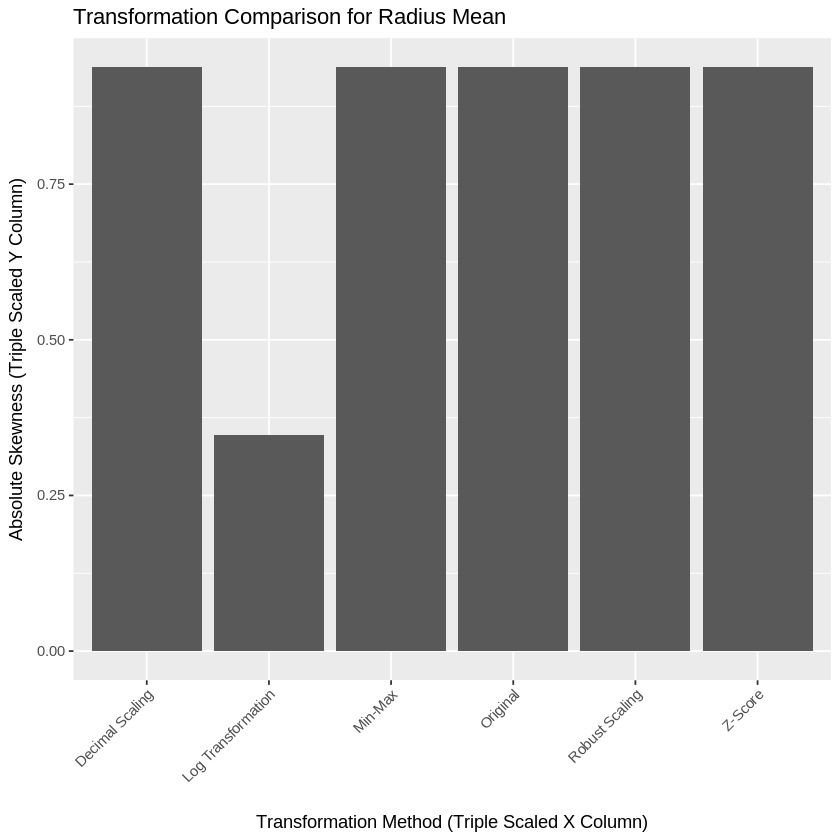

In [ ]:
# VISUAL COMPARISON
comparison_plot <- comparison_table[
  comparison_table$Variable ==
    "radius_mean",
  ,
  drop = FALSE
]

ggplot(
  comparison_plot,
  aes(
    x = Method,
    y = abs(Skewness)
  )
) +
  geom_col() +
  labs(
    title = "Transformation Comparison for Radius Mean",
    x = "Transformation Method (Triple Scaled X Column)",
    y = "Absolute Skewness (Triple Scaled Y Column)"
  ) +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    )
  )


# 13. Bivariate & Multivariate Analysis

`geom_smooth()` using formula = 'y ~ x'



	Pearson's product-moment correlation

data:  dl$radius_mean and dl$area_mean
t = 148.32, df = 567, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9851095 0.9892674
sample estimates:
      cor 
0.9873572 



Warning message in cor.test.default(dl$radius_mean, dl$area_mean, method = "spearman"):
“cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  dl$radius_mean and dl$area_mean
S = 12219, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
     rho 
0.999602 



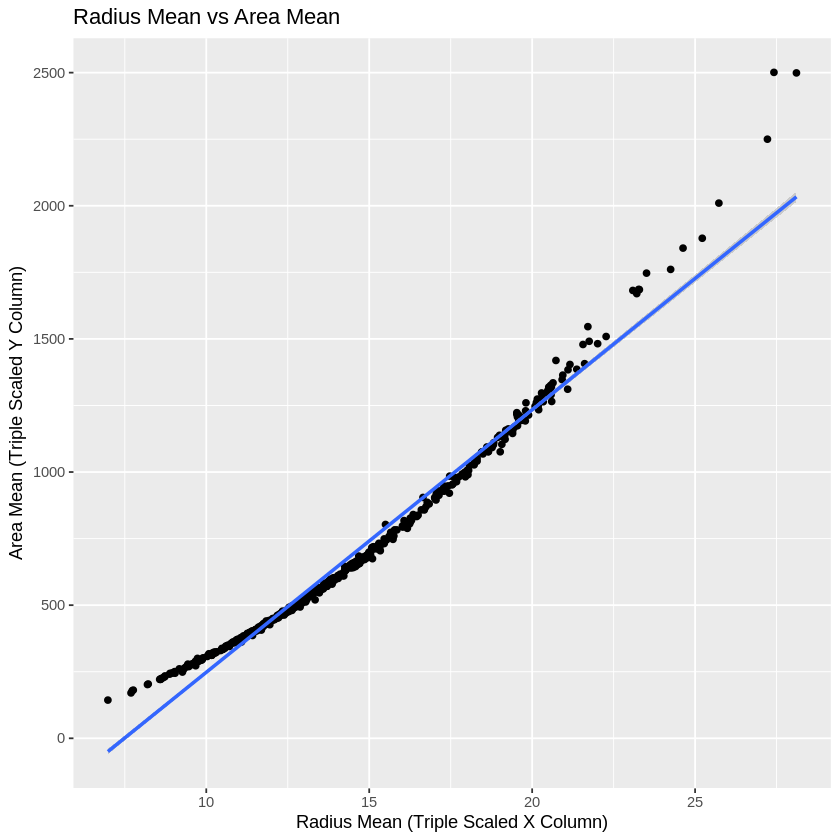

In [ ]:
# 1. NUMERIC VS NUMERIC
ggplot(
  dl,
  aes(
    x = radius_mean,
    y = area_mean
  )
) +
  geom_point() +
  geom_smooth(
    method = "lm",
    se = TRUE
  ) +
  labs(
    title = "Radius Mean vs Area Mean",
    x = "Radius Mean (Triple Scaled X Column)",
    y = "Area Mean (Triple Scaled Y Column)"
  )


# Pearson correlation
pearson_result <- cor.test(
  dl$radius_mean,
  dl$area_mean,
  method = "pearson"
)

print(pearson_result)


# Spearman correlation
spearman_result <- cor.test(
  dl$radius_mean,
  dl$area_mean,
  method = "spearman"
)

print(spearman_result)


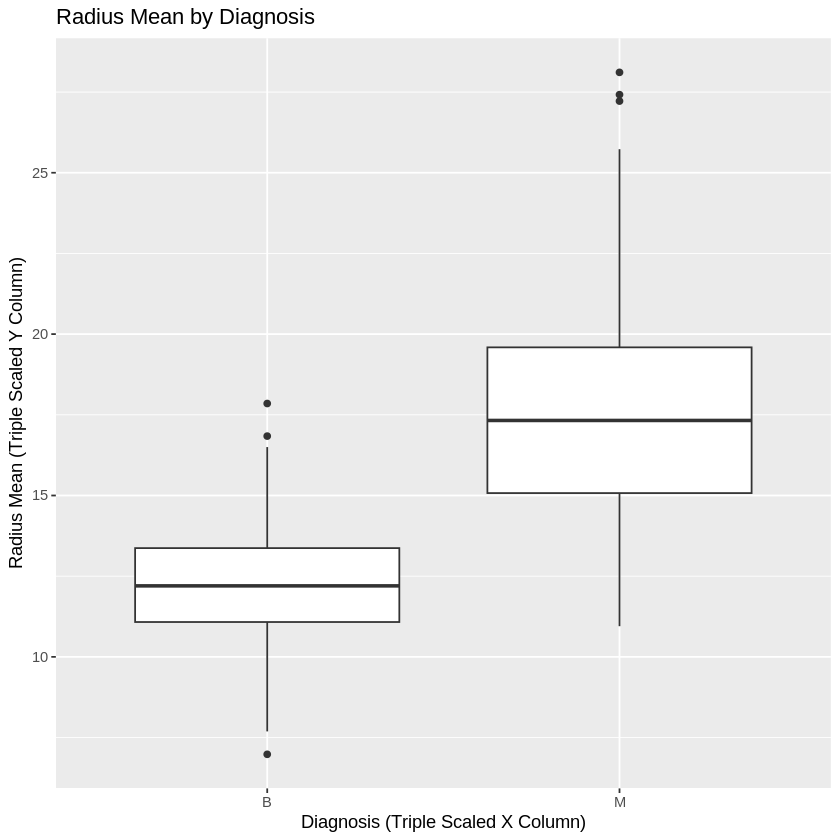

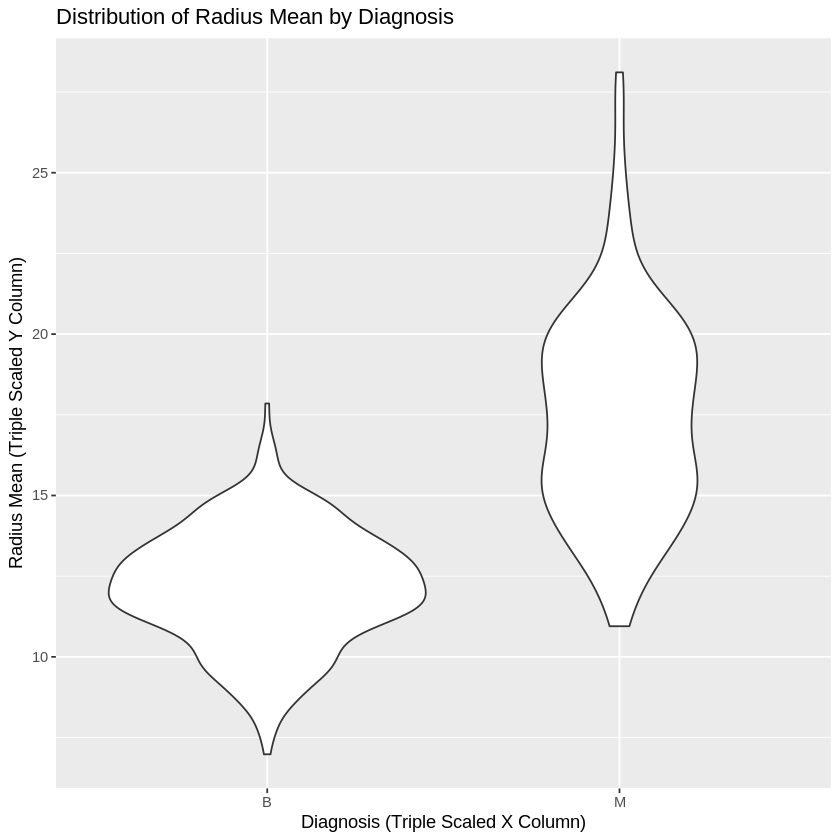

In [ ]:
# 2. NUMERIC VS CATEGORICAL
ggplot(
  dl,
  aes(
    x = diagnosis,
    y = radius_mean
  )
) +
  geom_boxplot() +
  labs(
    title = "Radius Mean by Diagnosis",
    x = "Diagnosis (Triple Scaled X Column)",
    y = "Radius Mean (Triple Scaled Y Column)"
  )


# Violin plot
# Shows the complete distribution shape.

ggplot(
  dl,
  aes(
    x = diagnosis,
    y = radius_mean
  )
) +
  geom_violin() +
  labs(
    title = "Distribution of Radius Mean by Diagnosis",
    x = "Diagnosis (Triple Scaled X Column)",
    y = "Radius Mean (Triple Scaled Y Column)"
  )

   
    Low Medium High
  B 306     51    0
  M  32    158   22


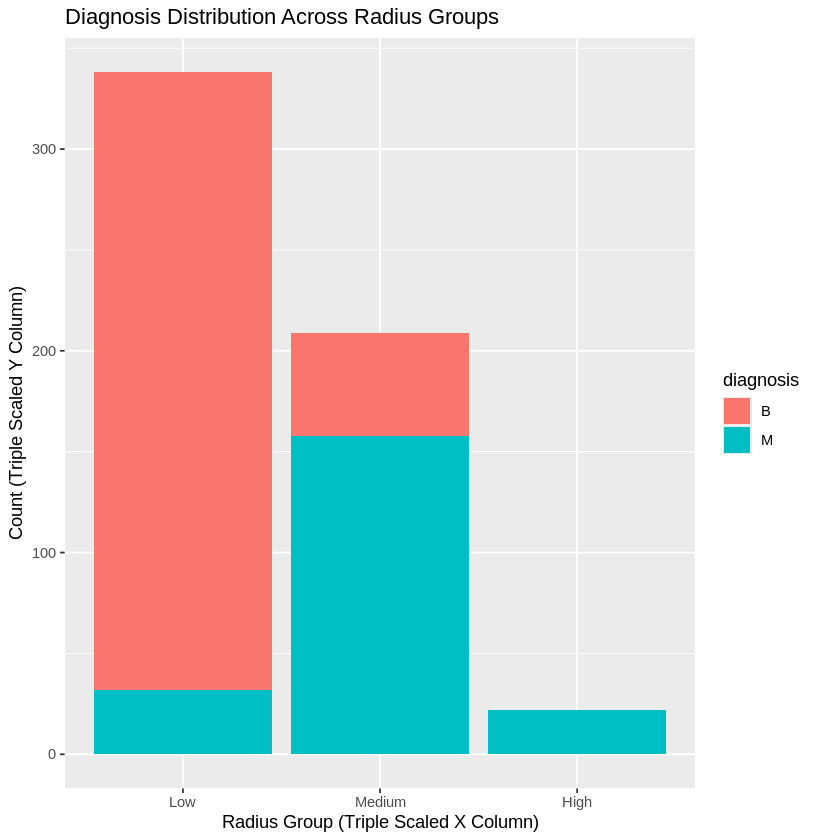

In [ ]:
# 3. CATEGORICAL VS CATEGORICAL
dl$radius_group <- cut(
  dl$radius_mean,
  breaks = 3,
  labels = c(
    "Low",
    "Medium",
    "High"
  )
)

# Cross-tabulation

cross_table <- table(
  dl$diagnosis,
  dl$radius_group
)

print(cross_table)


# Stacked bar chart
# Suitable for comparing two categorical variables.

ggplot(
  dl,
  aes(
    x = radius_group,
    fill = diagnosis
  )
) +
  geom_bar(
    position = "stack"
  ) +
  labs(
    title = "Diagnosis Distribution Across Radius Groups",
    x = "Radius Group (Triple Scaled X Column)",
    y = "Count (Triple Scaled Y Column)"
  )

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘ggstats’


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


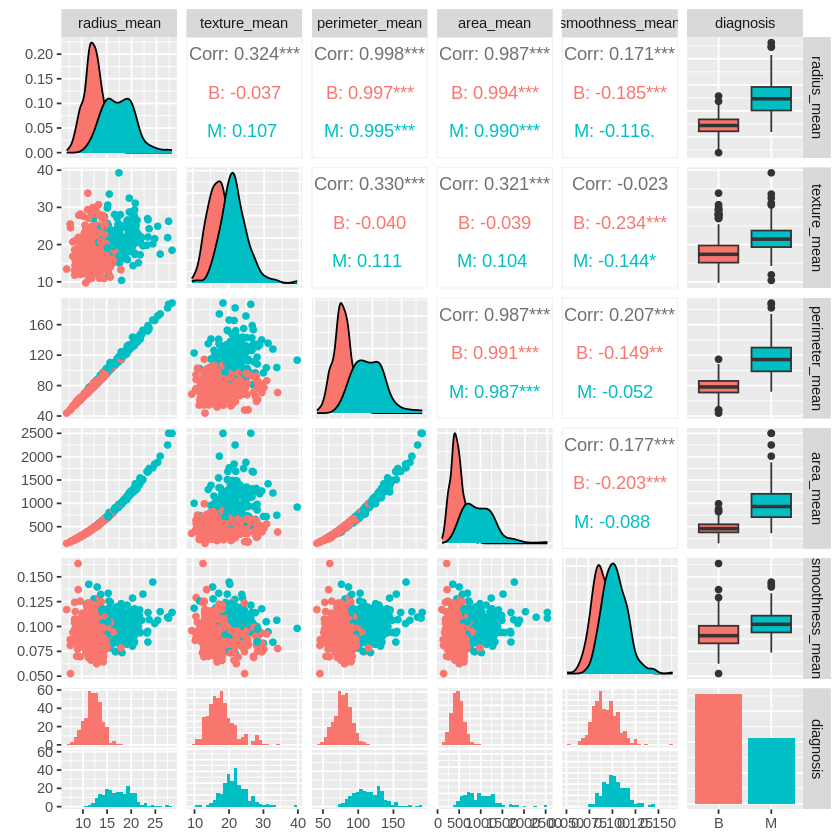

In [ ]:
# 4. MULTIVARIATE ANALYSIS: PAIR PLOT
if (!requireNamespace(
  "GGally",
  quietly = TRUE
)) {
  install.packages(
    "GGally",
  )
}

library(GGally)

# Select important numeric variables
pair_data <- dl[
  ,
  c(
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "diagnosis"
  )
]

# Pair plot

ggpairs(
  pair_data,
  mapping = aes(
    color = diagnosis
  )
)


In [ ]:
# 5. PRINCIPAL COMPONENT ANALYSIS (PCA)
# Select numeric predictors
pca_data <- dl[
  ,
  sapply(dl, is.numeric),
  drop = FALSE
]

# Remove rows with missing values
pca_data <- na.omit(
  pca_data
)

# Standardize before PCA
pca_result <- prcomp(
  pca_data,
  center = TRUE,
  scale. = TRUE
)

# PCA summary
summary(
  pca_result
)


Importance of components:
                          PC1    PC2     PC3     PC4     PC5     PC6     PC7
Standard deviation     3.6453 2.3868 1.68386 1.40761 1.28406 1.11116 0.98908
Proportion of Variance 0.4286 0.1838 0.09146 0.06391 0.05319 0.03983 0.03156
Cumulative Proportion  0.4286 0.6124 0.70388 0.76779 0.82098 0.86081 0.89237
                           PC8     PC9   PC10    PC11    PC12    PC13    PC14
Standard deviation     0.81961 0.67882 0.6349 0.59089 0.54212 0.51103 0.49125
Proportion of Variance 0.02167 0.01486 0.0130 0.01126 0.00948 0.00842 0.00778
Cumulative Proportion  0.91404 0.92890 0.9419 0.95317 0.96265 0.97107 0.97886
                          PC15    PC16    PC17   PC18   PC19    PC20   PC21
Standard deviation     0.39620 0.30680 0.28251 0.2430 0.2293 0.22163 0.1763
Proportion of Variance 0.00506 0.00304 0.00257 0.0019 0.0017 0.00158 0.0010
Cumulative Proportion  0.98392 0.98696 0.98953 0.9914 0.9931 0.99472 0.9957
                          PC22    PC23    PC24    

In [ ]:
# VARIANCE EXPLAINED BY EACH COMPONENT
variance_explained <- (
  pca_result$sdev^2
) / sum(
  pca_result$sdev^2
)

pca_variance_table <- data.frame(
  Component = paste0(
    "PC",
    1:length(
      variance_explained
    )
  ),
  Variance_Explained =
    variance_explained,
  Cumulative_Variance =
    cumsum(
      variance_explained
    )
)

print(
  pca_variance_table
)


   Component Variance_Explained Cumulative_Variance
1        PC1       4.286470e-01           0.4286470
2        PC2       1.837679e-01           0.6124149
3        PC3       9.146436e-02           0.7038793
4        PC4       6.391475e-02           0.7677940
5        PC5       5.318759e-02           0.8209816
6        PC6       3.982815e-02           0.8608098
7        PC7       3.155720e-02           0.8923670
8        PC8       2.166945e-02           0.9140364
9        PC9       1.486427e-02           0.9289007
10      PC10       1.300429e-02           0.9419050
11      PC11       1.126306e-02           0.9531681
12      PC12       9.480337e-03           0.9626484
13      PC13       8.424094e-03           0.9710725
14      PC14       7.784846e-03           0.9788573
15      PC15       5.063666e-03           0.9839210
16      PC16       3.036404e-03           0.9869574
17      PC17       2.574514e-03           0.9895319
18      PC18       1.904718e-03           0.9914366
19      PC19

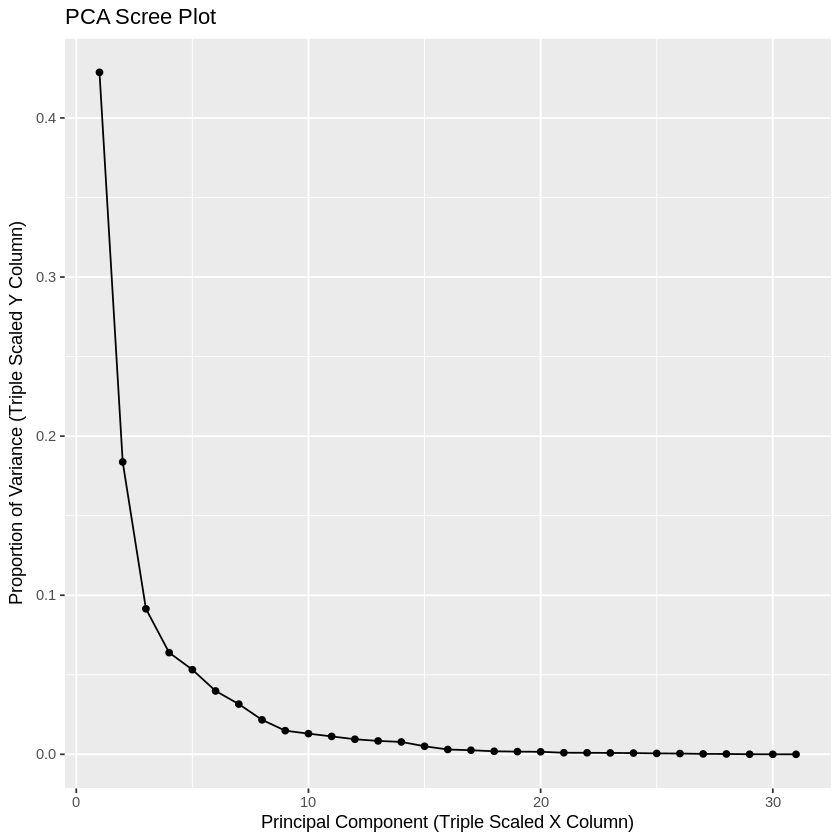

In [ ]:
# PCA SCREE PLOT
scree_data <- data.frame(
  Component = 1:length(
    variance_explained
  ),
  Variance = variance_explained
)

ggplot(
  scree_data,
  aes(
    x = Component,
    y = Variance
  )
) +
  geom_line() +
  geom_point() +
  labs(
    title = "PCA Scree Plot",
    x = "Principal Component (Triple Scaled X Column)",
    y = "Proportion of Variance (Triple Scaled Y Column)"
  )


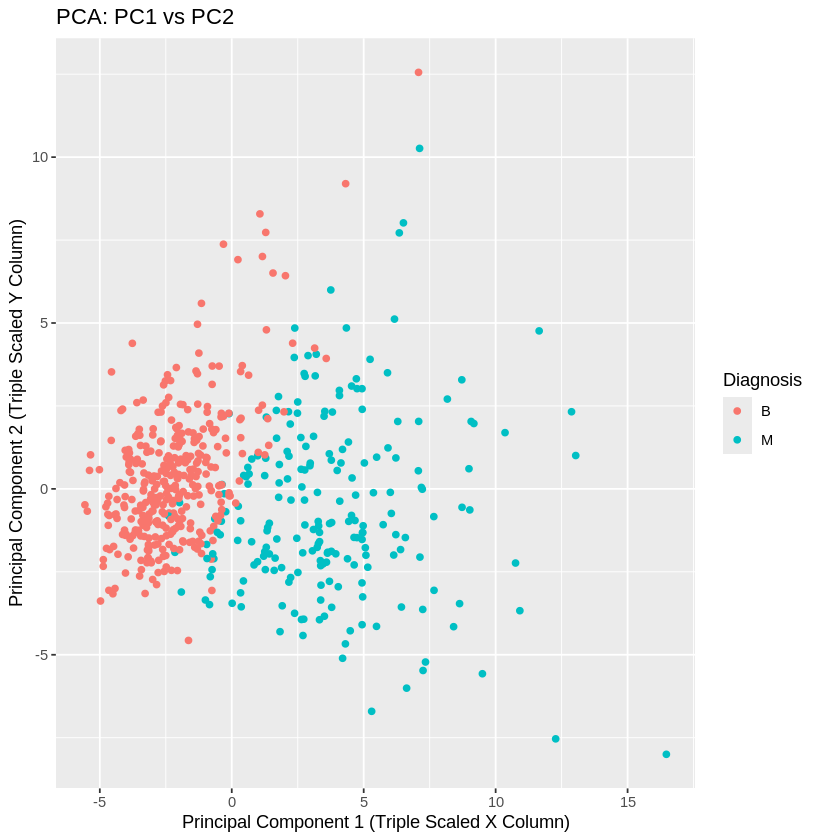

In [ ]:
# PCA: FIRST TWO COMPONENTS
pca_plot_data <- data.frame(
  PC1 = pca_result$x[, 1],
  PC2 = pca_result$x[, 2],
  Diagnosis = dl$diagnosis[
    as.numeric(
      rownames(pca_data)
    )
  ]
)

ggplot(
  pca_plot_data,
  aes(
    x = PC1,
    y = PC2,
    color = Diagnosis
  )
) +
  geom_point() +
  labs(
    title = "PCA: PC1 vs PC2",
    x = "Principal Component 1 (Triple Scaled X Column)",
    y = "Principal Component 2 (Triple Scaled Y Column)"
  )


# 14. Feature Engineering

In [ ]:
# 1. INTERACTION FEATURES

dl$radius_texture_interaction <-
  dl$radius_mean *
  dl$texture_mean

dl$perimeter_area_interaction <-
  dl$perimeter_mean *
  dl$area_mean

print(
  head(
    dl[
      ,
      c(
        "radius_texture_interaction",
        "perimeter_area_interaction"
      )
    ]
  )
)

  radius_texture_interaction perimeter_area_interaction
1                   186.7362                  122922.80
2                   365.5289                  176225.40
3                   418.4125                  156390.00
4                   232.7396                   29953.64
5                   290.9586                  175224.70
6                   195.4650                   39394.15


In [ ]:
# 2. RATIO FEATURES
dl$area_perimeter_ratio <-
  dl$area_mean /
  dl$perimeter_mean

dl$radius_perimeter_ratio <-
  dl$radius_mean /
  dl$perimeter_mean

print(
  head(
    dl[
      ,
      c(
        "area_perimeter_ratio",
        "radius_perimeter_ratio"
      )
    ]
  )
)

  area_perimeter_ratio radius_perimeter_ratio
1             8.151466              0.1464984
2             9.977427              0.1547780
3             9.253846              0.1514615
4             4.976798              0.1472029
5             9.600296              0.1501850
6             5.778128              0.1507812


In [ ]:
# 3. BINNING / DISCRETIZATION
dl$radius_category <- cut(
  dl$radius_mean,
  breaks = 3,
  labels = c(
    "Low",
    "Medium",
    "High"
  ),
  include.lowest = TRUE
)

print(
  table(
    dl$radius_category
  )
)


   Low Medium   High 
   338    209     22 


In [ ]:
# 4. POLYNOMIAL FEATURES
dl$radius_mean_squared <-
  dl$radius_mean^2

dl$area_mean_squared <-
  dl$area_mean^2

print(
  head(
    dl[
      ,
      c(
        "radius_mean_squared",
        "area_mean_squared"
      )
    ]
  )
)

  radius_mean_squared area_mean_squared
1            323.6401         1002001.0
2            423.1249         1758276.0
3            387.6961         1447209.0
4            130.4164          149073.2
5            411.6841         1682209.0
6            155.0025          227624.4


In [ ]:
# 5. DATE DECOMPOSITION
print(
  "No date/time column is available in this dataset."
)


[1] "No date/time column is available in this dataset."


In [ ]:
# 6. PCA COMPONENTS

pca_data <- dl[
  ,
  setdiff(
    names(dl),
    c(
      "id",
      "diagnosis",
      "radius_category"
    )
  ),
  drop = FALSE
]

# Select numeric columns only
pca_data <- pca_data[
  ,
  sapply(
    pca_data,
    is.numeric
  ),
  drop = FALSE
]

# Remove rows containing missing values
pca_data <- na.omit(
  pca_data
)

# Standardize and perform PCA
pca_result <- prcomp(
  pca_data,
  center = TRUE,
  scale. = TRUE
)

# Add first three PCA components
pca_features <- data.frame(
  PC1 = pca_result$x[
    ,
    1
  ],
  PC2 = pca_result$x[
    ,
    2
  ],
  PC3 = pca_result$x[
    ,
    3
  ]
)

print(
  head(
    pca_features
  )
)

        PC1        PC2        PC3
1 -8.716637  -4.020126 -1.1822925
2 -4.094567   4.054140 -0.5748228
3 -6.675218   0.448938 -0.5826873
4 -4.783472 -11.918879 -2.8122638
5 -5.319144   1.712706  1.3097056
6 -1.269564  -4.776195 -2.8000273


In [ ]:
# COMBINE ENGINEERED FEATURES
engineered_data <- cbind(
  dl,
  pca_features
)

print(
  head(
    engineered_data
  )
)

        id diagnosis radius_mean texture_mean perimeter_mean area_mean
1   842302         M       17.99        10.38         122.80    1001.0
2   842517         M       20.57        17.77         132.90    1326.0
3 84300903         M       19.69        21.25         130.00    1203.0
4 84348301         M       11.42        20.38          77.58     386.1
5 84358402         M       20.29        14.34         135.10    1297.0
6   843786         M       12.45        15.70          82.57     477.1
  smoothness_mean compactness_mean concavity_mean concave.points_mean
1         0.11840          0.27760         0.3001             0.14710
2         0.08474          0.07864         0.0869             0.07017
3         0.10960          0.15990         0.1974             0.12790
4         0.14250          0.28390         0.2414             0.10520
5         0.10030          0.13280         0.1980             0.10430
6         0.12780          0.17000         0.1578             0.08089
  symmetry_me

# 15. Missing Data: Imputation vs. Removal

In [ ]:
# 1. MISSING PERCENTAGE
missing_percentage <- (
  missing_count /
    nrow(dl)
) * 100

missing_table <- data.frame(
  Column = names(
    missing_count
  ),
  Missing_Count =
    as.numeric(
      missing_count
    ),
  Missing_Percentage =
    as.numeric(
      missing_percentage
    )
)

print(
  missing_table
)

                       Column Missing_Count Missing_Percentage
1                          id             0                  0
2                   diagnosis             0                  0
3                 radius_mean             0                  0
4                texture_mean             0                  0
5              perimeter_mean             0                  0
6                   area_mean             0                  0
7             smoothness_mean             0                  0
8            compactness_mean             0                  0
9              concavity_mean             0                  0
10        concave.points_mean             0                  0
11              symmetry_mean             0                  0
12     fractal_dimension_mean             0                  0
13                  radius_se             0                  0
14                 texture_se             0                  0
15               perimeter_se             0            

In [ ]:
# 2. REMOVE COLUMNS WITH MORE THAN 50% MISSING VALUES
columns_to_remove <- names(
  missing_percentage[
    missing_percentage > 50
  ]
)

if (
  length(
    columns_to_remove
  ) > 0
) {

  dl <- dl[
    ,
    !names(dl) %in%
      columns_to_remove,
    drop = FALSE
  ]
}

In [ ]:
# 3. REMOVE ROWS WITH MISSING TARGET VALUES
if (
  "diagnosis" %in%
  names(dl)
) {

  dl <- dl[
    !is.na(
      dl$diagnosis
    ),
    ,
    drop = FALSE
  ]
}

In [ ]:
# 4. REMOVE COMPLETELY EMPTY COLUMNS
empty_columns <- names(
  dl[
    ,
    sapply(
      dl,
      function(x) {
        all(
          is.na(x)
        )
      }
    ),
    drop = FALSE
  ]
)

if (
  length(
    empty_columns
  ) > 0
) {

  dl <- dl[
    ,
    !names(dl) %in%
      empty_columns,
    drop = FALSE
  ]
}


In [ ]:
# 5. MEDIAN IMPUTATION FOR NUMERIC VARIABLES
numeric_columns <- names(
  dl[
    ,
    sapply(
      dl,
      is.numeric
    ),
    drop = FALSE
  ]
)

for (
  column in numeric_columns
) {

  median_value <- median(
    dl[
      ,
      column
    ],
    na.rm = TRUE
  )

  dl[
    is.na(
      dl[
        ,
        column
      ]
    ),
    column
  ] <- median_value
}

In [ ]:
# 6. MODE IMPUTATION FOR CATEGORICAL VARIABLES
get_mode <- function(x) {

  values <- unique(
    x[
      !is.na(x)
    ]
  )

  values[
    which.max(
      tabulate(
        match(
          x,
          values
        )
      )
    )
  ]
}


categorical_columns <- names(
  dl[
    ,
    sapply(
      dl,
      function(x) {
        is.character(x) ||
          is.factor(x)
      }
    ),
    drop = FALSE
  ]
)

for (
  column in categorical_columns
) {

  mode_value <- get_mode(
    dl[
      ,
      column
    ]
  )

  dl[
    is.na(
      dl[
        ,
        column
      ]
    ),
    column
  ] <- mode_value
}


In [ ]:
# 7. MULTIPLE IMPUTATION USING MICE
if (!requireNamespace(
  "mice",
  quietly = TRUE
)) {
  install.packages(
    "mice",
  )
}

library(mice)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘reformulas’, ‘ucminf’, ‘lme4’, ‘ordinal’, ‘pan’, ‘jomo’, ‘glmnet’, ‘mitml’



Attaching package: ‘mice’


The following object is masked from ‘package:stats’:

    filter


The following objects are masked from ‘package:base’:

    cbind, rbind




# 16. Train / Validation / Test Split

In [ ]:
# Remove rows with missing target values
dl <- dl[
  !is.na(
    dl$diagnosis
  ),
  ,
  drop = FALSE
]
# Convert target variable to factor
dl$diagnosis <- as.factor(
  dl$diagnosis
)


In [ ]:
library(caret)
# STRATIFIED 70/15/15 SPLIT
train_index <- createDataPartition(
  dl$diagnosis,
  p = 0.70,
  list = FALSE
)

train_data <- dl[
  train_index,
  ,
  drop = FALSE
]

remaining_data <- dl[
  -train_index,
  ,
  drop = FALSE
]

Loading required package: ggplot2

Loading required package: lattice



In [ ]:
# Split remaining 30% into:
# 15% validation
# 15% test

set.seed(123)

validation_index <- createDataPartition(
  remaining_data$diagnosis,
  p = 0.50,
  list = FALSE
)

validation_data <- remaining_data[
  validation_index,
  ,
  drop = FALSE
]

test_data <- remaining_data[
  -validation_index,
  ,
  drop = FALSE
]

In [ ]:
# CHECK DATASET SIZES
split_summary <- data.frame(
  Dataset = c(
    "Training",
    "Validation",
    "Test"
  ),

  Rows = c(
    nrow(train_data),
    nrow(validation_data),
    nrow(test_data)
  ),

  Percentage = c(
    nrow(train_data) /
      nrow(dl) * 100,

    nrow(validation_data) /
      nrow(dl) * 100,

    nrow(test_data) /
      nrow(dl) * 100
  )
)

print(
  split_summary
)


     Dataset Rows Percentage
1   Training  399   70.12302
2 Validation   86   15.11424
3       Test   84   14.76274


In [ ]:
# CHECK CLASS PROPORTIONS
print(
  prop.table(
    table(
      dl$diagnosis
    )
  )
)

print(
  prop.table(
    table(
      train_data$diagnosis
    )
  )
)

print(
  prop.table(
    table(
      validation_data$diagnosis
    )
  )
)

print(
  prop.table(
    table(
      test_data$diagnosis
    )
  )
)



        B         M 
0.6274165 0.3725835 

        B         M 
0.6265664 0.3734336 

       B        M 
0.627907 0.372093 

        B         M 
0.6309524 0.3690476 


In [ ]:
# DATA LEAKAGE-SAFE STANDARDIZATION
numeric_columns <- names(
  train_data[
    ,
    sapply(
      train_data,
      is.numeric
    ),
    drop = FALSE
  ]
)

# Remove ID from model preprocessing
numeric_columns <- setdiff(
  numeric_columns,
  "id"
)


# Calculate training statistics

train_means <- sapply(
  train_data[
    ,
    numeric_columns,
    drop = FALSE
  ],
  mean,
  na.rm = TRUE
)

train_sds <- sapply(
  train_data[
    ,
    numeric_columns,
    drop = FALSE
  ],
  sd,
  na.rm = TRUE
)


# Scaling function

scale_using_training_stats <- function(
    data,
    columns,
    means,
    sds
) {

  result <- data

  for (
    column in columns
  ) {

    result[
      ,
      column
    ] <- (
      result[
        ,
        column
      ] -
        means[
          column
        ]
    ) /
      sds[
        column
      ]
  }

  return(
    result
  )
}


In [ ]:
# Apply training statistics
# to all three datasets.

train_scaled <- scale_using_training_stats(
  train_data,
  numeric_columns,
  train_means,
  train_sds
)

validation_scaled <- scale_using_training_stats(
  validation_data,
  numeric_columns,
  train_means,
  train_sds
)

test_scaled <- scale_using_training_stats(
  test_data,
  numeric_columns,
  train_means,
  train_sds
)

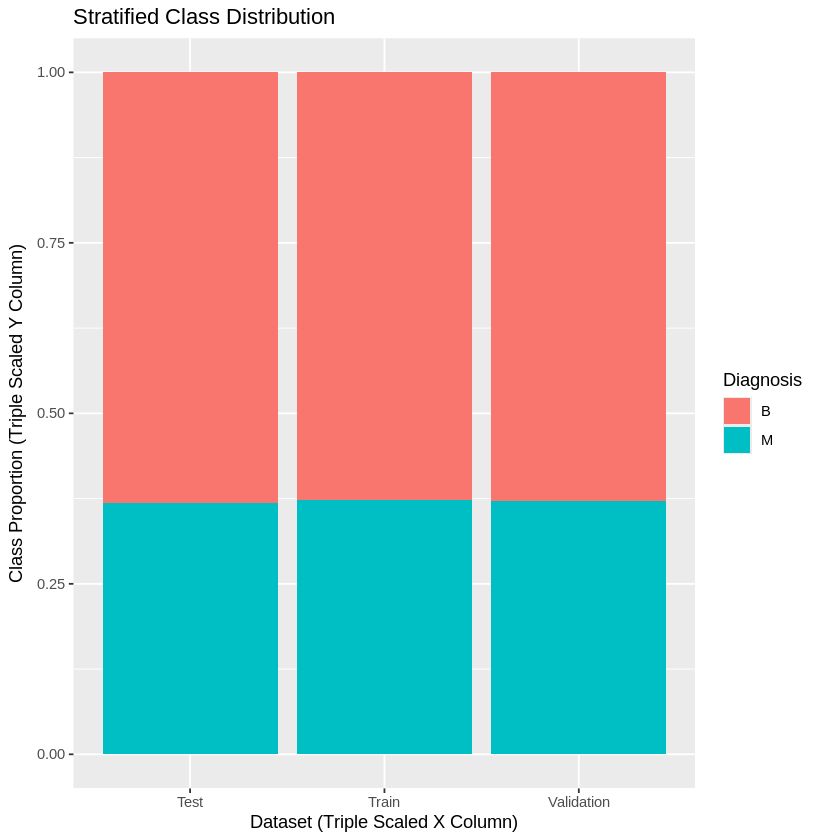

In [ ]:
# VISUALIZATION
class_distribution <- data.frame(
  Dataset = c(
    rep(
      "Train",
      nrow(train_data)
    ),
    rep(
      "Validation",
      nrow(validation_data)
    ),
    rep(
      "Test",
      nrow(test_data)
    )
  ),

  Diagnosis = c(
    as.character(
      train_data$diagnosis
    ),
    as.character(
      validation_data$diagnosis
    ),
    as.character(
      test_data$diagnosis
    )
  )
)

ggplot(
  class_distribution,
  aes(
    x = Dataset,
    fill = Diagnosis
  )
) +
  geom_bar(
    position = "fill"
  ) +
  labs(
    title = "Stratified Class Distribution",
    x = "Dataset (Triple Scaled X Column)",
    y = "Class Proportion (Triple Scaled Y Column)"
  )


# 17. Model Building

In [ ]:
# INSTALL REQUIRED PACKAGES
packages <- c(
  "caret",
  "rpart",
  "randomForest",
  "MASS"
)

for (
  package_name in packages
) {

  if (
    !requireNamespace(
      package_name,
      quietly = TRUE
    )
  ) {

    install.packages(
      package_name,
    )
  }
}


library(caret)
library(rpart)
library(randomForest)
library(MASS)

In [ ]:
# STRATIFIED TRAIN / VALIDATION / TEST SPLIT
set.seed(
  123
)

# 70% Training data
train_index <- createDataPartition(
  dl$diagnosis,
  p = 0.70,
  list = FALSE
)

train_data <- dl[
  train_index,
  ,
  drop = FALSE
]

remaining_data <- dl[
  -train_index,
  ,
  drop = FALSE
]


# Split remaining 30% equally:
# 15% Validation
# 15% Test

set.seed(
  123
)

validation_index <- createDataPartition(
  remaining_data$diagnosis,
  p = 0.50,
  list = FALSE
)

validation_data <- remaining_data[
  validation_index,
  ,
  drop = FALSE
]

test_data <- remaining_data[
  -validation_index,
  ,
  drop = FALSE
]


In [ ]:
# SELECT PREDICTOR VARIABLES
predictor_columns <- setdiff(
  names(
    train_data
  ),
  "diagnosis"
)
# Keep only numeric predictors
predictor_columns <- predictor_columns[
  sapply(
    train_data[
      ,
      predictor_columns,
      drop = FALSE
    ],
    is.numeric
  )
]


In [ ]:
# REMOVE ZERO-VARIANCE PREDICTORS
zero_variance_columns <- predictor_columns[
  sapply(
    train_data[
      ,
      predictor_columns,
      drop = FALSE
    ],
    function(x) {

      length(
        unique(
          x[
            !is.na(x)
          ]
        )
      ) <= 1
    }
  )
]

predictor_columns <- setdiff(
  predictor_columns,
  zero_variance_columns
)


In [ ]:
# FORMULA
model_formula <- as.formula(
  paste(
    "diagnosis ~",
    paste(
      predictor_columns,
      collapse = " + "
    )
  )
)

In [ ]:
# LOGISTIC REGRESSION
logistic_model <- glm(
  model_formula,
  data = train_data,
  family = binomial
)

logistic_probability <- predict(
  logistic_model,
  newdata = validation_data,
  type = "response"
)

# Determine the positive class
positive_class <- levels(
  train_data$diagnosis
)[2]

negative_class <- levels(
  train_data$diagnosis
)[1]

logistic_prediction <- ifelse(
  logistic_probability >= 0.5,
  positive_class,
  negative_class
)

logistic_prediction <- factor(
  logistic_prediction,
  levels = levels(
    train_data$diagnosis
  )
)

logistic_results <- confusionMatrix(
  logistic_prediction,
  validation_data$diagnosis,
  positive = positive_class
)

print(
  logistic_results
)



Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Confusion Matrix and Statistics

          Reference
Prediction  B  M
         B 51  4
         M  3 28
                                          
               Accuracy : 0.9186          
                 95% CI : (0.8395, 0.9666)
    No Information Rate : 0.6279          
    P-Value [Acc > NIR] : 6.699e-10       
                                          
                  Kappa : 0.8247          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 0.8750          
            Specificity : 0.9444          
         Pos Pred Value : 0.9032          
         Neg Pred Value : 0.9273          
             Prevalence : 0.3721          
         Detection Rate : 0.3256          
   Detection Prevalence : 0.3605          
      Balanced Accuracy : 0.9097          
                                          
       'Positive' Class : M               
                                    

In [ ]:
# DECISION TREE
tree_model <- rpart(
  model_formula,
  data = train_data,
  method = "class"
)

tree_prediction <- predict(
  tree_model,
  newdata = validation_data,
  type = "class"
)

tree_results <- confusionMatrix(
  tree_prediction,
  validation_data$diagnosis,
  positive = positive_class
)

print(
  tree_results
)


Confusion Matrix and Statistics

          Reference
Prediction  B  M
         B 50  4
         M  4 28
                                         
               Accuracy : 0.907          
                 95% CI : (0.8249, 0.959)
    No Information Rate : 0.6279         
    P-Value [Acc > NIR] : 4.026e-09      
                                         
                  Kappa : 0.8009         
                                         
 Mcnemar's Test P-Value : 1              
                                         
            Sensitivity : 0.8750         
            Specificity : 0.9259         
         Pos Pred Value : 0.8750         
         Neg Pred Value : 0.9259         
             Prevalence : 0.3721         
         Detection Rate : 0.3256         
   Detection Prevalence : 0.3721         
      Balanced Accuracy : 0.9005         
                                         
       'Positive' Class : M              
                                         


In [ ]:
# RANDOM FOREST
set.seed(
  123
)

random_forest_model <- randomForest(
  model_formula,
  data = train_data,
  ntree = 500,
  importance = TRUE
)

random_forest_prediction <- predict(
  random_forest_model,
  newdata = validation_data,
  type = "class"
)

random_forest_results <- confusionMatrix(
  random_forest_prediction,
  validation_data$diagnosis,
  positive = positive_class
)

print(
  random_forest_results
)


Confusion Matrix and Statistics

          Reference
Prediction  B  M
         B 53  2
         M  1 30
                                          
               Accuracy : 0.9651          
                 95% CI : (0.9014, 0.9927)
    No Information Rate : 0.6279          
    P-Value [Acc > NIR] : 9.413e-14       
                                          
                  Kappa : 0.9249          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 0.9375          
            Specificity : 0.9815          
         Pos Pred Value : 0.9677          
         Neg Pred Value : 0.9636          
             Prevalence : 0.3721          
         Detection Rate : 0.3488          
   Detection Prevalence : 0.3605          
      Balanced Accuracy : 0.9595          
                                          
       'Positive' Class : M               
                                    

In [ ]:
if (
  !requireNamespace(
    "gbm",
    quietly = TRUE
  )
) {

  install.packages(
    "gbm",
  )
}

library(gbm)

In [ ]:
# GRADIENT BOOSTING MACHINE
train_gbm <- train_data

validation_gbm <- validation_data

train_gbm$target_numeric <- ifelse(
  train_gbm$diagnosis ==
    positive_class,
  1,
  0
)

validation_gbm$target_numeric <- ifelse(
  validation_gbm$diagnosis ==
    positive_class,
  1,
  0
)

gbm_formula <- as.formula(
  paste(
    "target_numeric ~",
    paste(
      predictor_columns,
      collapse = " + "
    )
  )
)

set.seed(
  123
)

gbm_model <- gbm(
  gbm_formula,
  data = train_gbm,
  distribution = "bernoulli",
  n.trees = 100,
  interaction.depth = 3,
  shrinkage = 0.05,
  n.minobsinnode = 10,
  verbose = FALSE
)

gbm_probability <- predict(
  gbm_model,
  newdata = validation_gbm,
  n.trees = 100,
  type = "response"
)

gbm_prediction <- ifelse(
  gbm_probability >= 0.5,
  positive_class,
  negative_class
)

gbm_prediction <- factor(
  gbm_prediction,
  levels = levels(
    train_data$diagnosis
  )
)

gbm_results <- confusionMatrix(
  gbm_prediction,
  validation_data$diagnosis,
  positive = positive_class
)

print(
  gbm_results
)



Confusion Matrix and Statistics

          Reference
Prediction  B  M
         B 53  2
         M  1 30
                                          
               Accuracy : 0.9651          
                 95% CI : (0.9014, 0.9927)
    No Information Rate : 0.6279          
    P-Value [Acc > NIR] : 9.413e-14       
                                          
                  Kappa : 0.9249          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 0.9375          
            Specificity : 0.9815          
         Pos Pred Value : 0.9677          
         Neg Pred Value : 0.9636          
             Prevalence : 0.3721          
         Detection Rate : 0.3488          
   Detection Prevalence : 0.3605          
      Balanced Accuracy : 0.9595          
                                          
       'Positive' Class : M               
                                    

In [ ]:
#  MODEL COMPARISON
model_comparison <- data.frame(

  Model = c(
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting"
  ),

  Accuracy = c(
    logistic_results$overall[
      "Accuracy"
    ],

    tree_results$overall[
      "Accuracy"
    ],

    random_forest_results$overall[
      "Accuracy"
    ],

    gbm_results$overall[
      "Accuracy"
    ]
  ),

  Sensitivity = c(
    logistic_results$byClass[
      "Sensitivity"
    ],

    tree_results$byClass[
      "Sensitivity"
    ],

    random_forest_results$byClass[
      "Sensitivity"
    ],

    gbm_results$byClass[
      "Sensitivity"
    ]
  ),

  Specificity = c(
    logistic_results$byClass[
      "Specificity"
    ],

    tree_results$byClass[
      "Specificity"
    ],

    random_forest_results$byClass[
      "Specificity"
    ],

    gbm_results$byClass[
      "Specificity"
    ]
  )
)


print(
  model_comparison
)


                Model  Accuracy Sensitivity Specificity
1 Logistic Regression 0.9186047      0.8750   0.9444444
2       Decision Tree 0.9069767      0.8750   0.9259259
3       Random Forest 0.9651163      0.9375   0.9814815
4   Gradient Boosting 0.9651163      0.9375   0.9814815


# 18. Model Evaluation Metrics — 20 Metrics

In [ ]:
# 1. INSTALL REQUIRED PACKAGE
required_packages <- c(
  "pROC",
  "MLmetrics"
)


for (
  package_name in required_packages
) {

  if (
    !requireNamespace(
      package_name,
      quietly = TRUE
    )
  ) {

    install.packages(
      package_name
    )
  }
}

library(
  pROC
)

library(
  MLmetrics
)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘gtools’, ‘caTools’, ‘gplots’, ‘ROCR’


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var



Attaching package: ‘MLmetrics’


The following objects are masked from ‘package:caret’:

    MAE, RMSE


The following object is masked from ‘package:base’:

    Recall




In [ ]:
# ACTUAL AND PREDICTED VALUES

actual <- validation_data$diagnosis

predicted <- random_forest_prediction

# Ensure both variables have the same factor levels
actual <- factor(
  actual
)

predicted <- factor(
  predicted,
  levels = levels(
    actual
  )
)

In [ ]:
# IDENTIFY POSITIVE CLASS

class_levels <- levels(
  actual
)

positive_class <- class_levels[2]

negative_class <- class_levels[1]

In [ ]:
# CONFUSION MATRIX
confusion_matrix <- confusionMatrix(
  predicted,
  actual,
  positive = positive_class
)

print(
  confusion_matrix
)

Confusion Matrix and Statistics

          Reference
Prediction  B  M
         B 53  2
         M  1 30
                                          
               Accuracy : 0.9651          
                 95% CI : (0.9014, 0.9927)
    No Information Rate : 0.6279          
    P-Value [Acc > NIR] : 9.413e-14       
                                          
                  Kappa : 0.9249          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 0.9375          
            Specificity : 0.9815          
         Pos Pred Value : 0.9677          
         Neg Pred Value : 0.9636          
             Prevalence : 0.3721          
         Detection Rate : 0.3488          
   Detection Prevalence : 0.3605          
      Balanced Accuracy : 0.9595          
                                          
       'Positive' Class : M               
                                    

In [ ]:
# Extract confusion matrix values

TP <- confusion_matrix$table[
  positive_class,
  positive_class
]

TN <- confusion_matrix$table[
  negative_class,
  negative_class
]

FP <- confusion_matrix$table[
  positive_class,
  negative_class
]

FN <- confusion_matrix$table[
  negative_class,
  positive_class
]

In [ ]:
# ACCURACY
accuracy <- (
  TP + TN
) /
(
  TP + TN + FP + FN
)

In [ ]:
# PRECISION
precision <- TP / (
  TP + FP
)

In [ ]:
# RECALL / SENSITIVITY
sensitivity <- TP / (
  TP + FN
)

In [ ]:
# SPECIFICITY
specificity <- TN / (
  TN + FP
)


In [ ]:
# F1-SCORE
f1_score <- 2 * (

  precision *
    sensitivity

) / (

  precision +
    sensitivity

)

In [ ]:
# BALANCED ACCURACY
balanced_accuracy <- (

  sensitivity +
    specificity

) / 2

In [ ]:
# COHEN'S KAPPA
cohen_kappa <- confusion_matrix$overall[
  "Kappa"
]

In [ ]:
# RANDOM FOREST PROBABILITY
random_forest_probability_all <- predict(
  random_forest_model,
  newdata = validation_data,
  type = "prob"
)

# Select probability of the positive class
random_forest_probability <-
  random_forest_probability_all[
    ,
    positive_class
  ]

In [ ]:
# AUC-ROC
predicted_probability <- random_forest_probability
roc_object <- roc(
  response = actual,
  predictor = predicted_probability,
  levels = c(
    negative_class,
    positive_class
  ),
  direction = "<"
)


auc_roc <- as.numeric(
  auc(
    roc_object
  )
)


In [ ]:
# LOG LOSS
epsilon <- 1e-15

predicted_probability <- pmin(
  pmax(
    predicted_probability,
    epsilon
  ),
  1 - epsilon
)


actual_binary <- ifelse(
  actual ==
    positive_class,
  1,
  0
)


log_loss <- -mean(

  actual_binary *
    log(
      predicted_probability
    ) +

    (
      1 -
        actual_binary
    ) *

    log(
      1 -
        predicted_probability
    )
)


In [ ]:
# MATTHEWS CORRELATION COEFFICIENT
mcc_denominator <- sqrt(

  (
    TP + FP
  ) *

  (
    TP + FN
  ) *

  (
    TN + FP
  ) *

  (
    TN + FN
  )
)


if (
  mcc_denominator == 0
) {

  mcc <- NA

} else {

  mcc <- (

    (
      TP * TN
    ) -

    (
      FP * FN
    )

  ) /

    mcc_denominator
}


In [ ]:
# FINAL METRICS TABLE
evaluation_metrics <- data.frame(

  Metric = c(
    "Accuracy",
    "Precision",
    "Recall / Sensitivity",
    "Specificity",
    "F1-Score",
    "Balanced Accuracy",
    "Cohen's Kappa",
    "AUC-ROC",
    "Log Loss",
    "Matthews Correlation Coefficient"
  ),

  Value = c(
    accuracy,
    precision,
    sensitivity,
    specificity,
    f1_score,
    balanced_accuracy,
    cohen_kappa,
    auc_roc,
    log_loss,
    mcc
  )
)


print(
  evaluation_metrics
)


                             Metric     Value
1                          Accuracy 0.9651163
2                         Precision 0.9677419
3              Recall / Sensitivity 0.9375000
4                       Specificity 0.9814815
5                          F1-Score 0.9523810
6                 Balanced Accuracy 0.9594907
7                     Cohen's Kappa 0.9248690
8                           AUC-ROC 0.9849537
9                          Log Loss 0.1589839
10 Matthews Correlation Coefficient 0.9251591


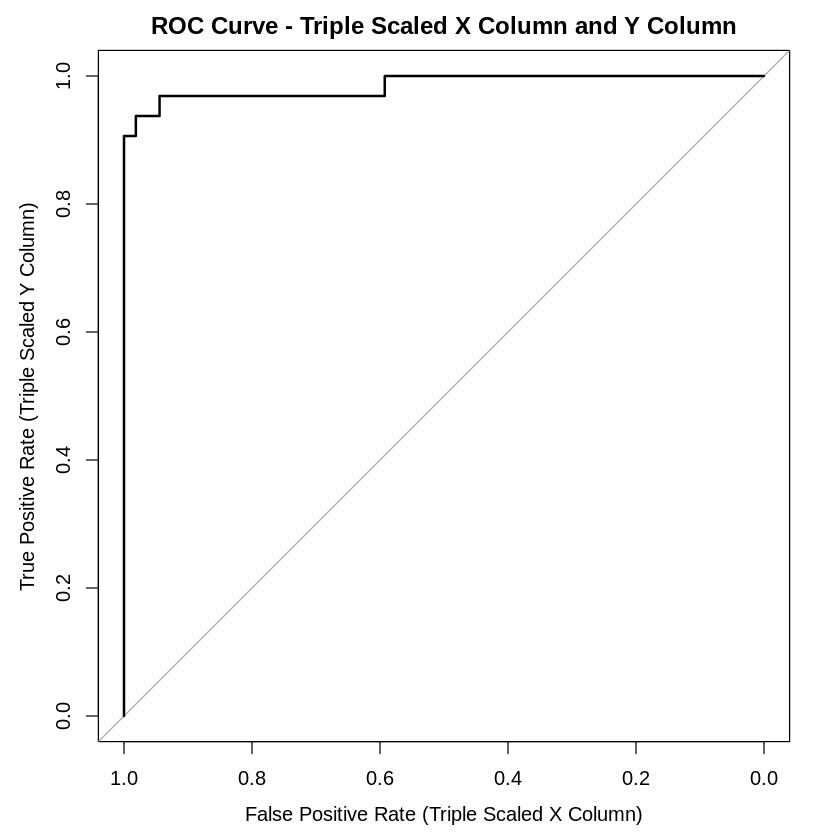

In [ ]:
# AUC-ROC VISUALIZATION
plot(
  roc_object,

  main =
    "ROC Curve - Triple Scaled X Column and Y Column",

  xlab =
    "False Positive Rate (Triple Scaled X Column)",

  ylab =
    "True Positive Rate (Triple Scaled Y Column)"
)


In [ ]:
# INTERPRETATION
cat(
  "\nEvaluation Interpretation:\n"
)


cat(
  "\nAccuracy:",
  round(
    accuracy,
    4
  )
)


cat(
  "\nPrecision:",
  round(
    precision,
    4
  )
)


cat(
  "\nSensitivity / Recall:",
  round(
    sensitivity,
    4
  )
)


cat(
  "\nSpecificity:",
  round(
    specificity,
    4
  )
)


cat(
  "\nF1-Score:",
  round(
    f1_score,
    4
  )
)


cat(
  "\nBalanced Accuracy:",
  round(
    balanced_accuracy,
    4
  )
)


cat(
  "\nCohen's Kappa:",
  round(
    cohen_kappa,
    4
  )
)


cat(
  "\nAUC-ROC:",
  round(
    auc_roc,
    4
  )
)


cat(
  "\nLog Loss:",
  round(
    log_loss,
    4
  )
)


cat(
  "\nMCC:",
  round(
    mcc,
    4
  )
)



Evaluation Interpretation:

Accuracy: 0.9651
Precision: 0.9677
Sensitivity / Recall: 0.9375
Specificity: 0.9815
F1-Score: 0.9524
Balanced Accuracy: 0.9595
Cohen's Kappa: 0.9249
AUC-ROC: 0.985
Log Loss: 0.159
MCC: 0.9252

# 19. Evaluation Curves & Visual Model Comparison

In [ ]:
# PREPARE ACTUAL VALUES
actual <- validation_data$diagnosis

class_levels <- levels(
  actual
)

negative_class <- class_levels[1]

positive_class <- class_levels[2]


In [ ]:
# RANDOM FOREST PROBABILITY
# Generate probability predictions
random_forest_probability_all <- predict(
  random_forest_model,
  newdata = validation_data,
  type = "prob"
)


# Extract probability of positive class
random_forest_probability <-
  random_forest_probability_all[
    ,
    positive_class
  ]

In [ ]:
# ROC CURVE
roc_object <- roc(
  response =
    actual,

  predictor =
    random_forest_probability,

  levels = c(
    negative_class,
    positive_class
  ),

  direction =
    "<"
)


auc_value <- as.numeric(
  auc(
    roc_object
  )
)


print(
  paste(
    "AUC-ROC:",
    round(
      auc_value,
      4
    )
  )
)


[1] "AUC-ROC: 0.985"


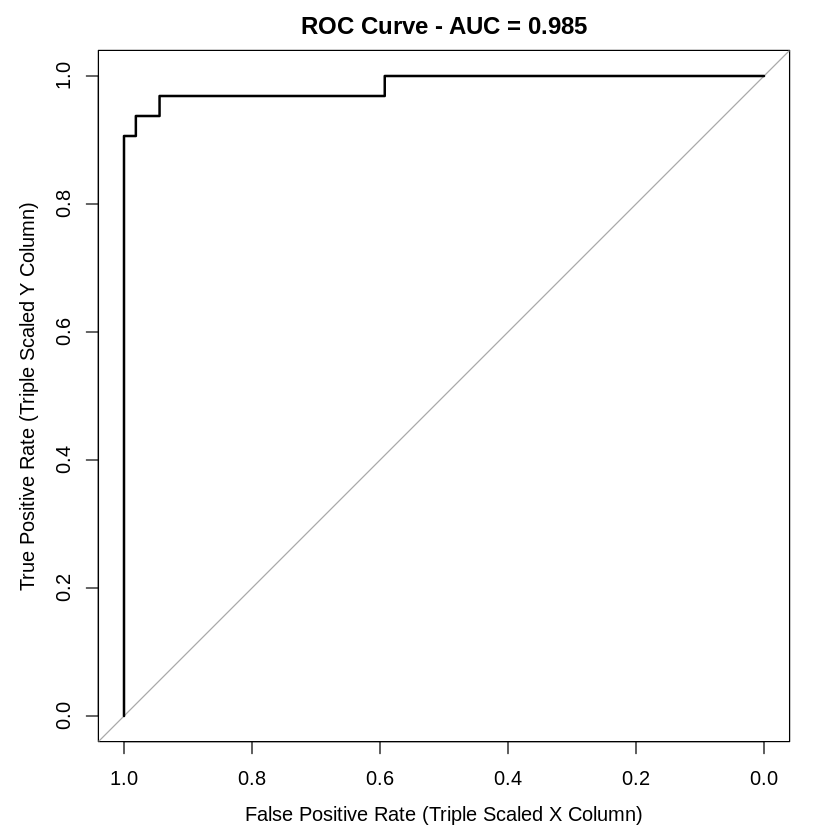

In [ ]:
# ROC VISUALIZATION
plot(
  roc_object,

  main =
    paste(
      "ROC Curve - AUC =",
      round(
        auc_value,
        4
      )
    ),

  xlab =
    "False Positive Rate (Triple Scaled X Column)",

  ylab =
    "True Positive Rate (Triple Scaled Y Column)"
)

In [ ]:
install.packages("PRROC")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# PRECISION-RECALL CURVE
library(PRROC)
actual_binary <- ifelse(
  actual ==
    positive_class,
  1,
  0
)


pr_object <- pr.curve(

  scores.class0 =
    random_forest_probability[
      actual_binary ==
        1
    ],

  scores.class1 =
    random_forest_probability[
      actual_binary ==
        0
    ],

  curve =
    TRUE
)


print(
  pr_object
)


Loading required package: rlang




  Precision-recall curve

    Area under curve (Integral):
     0.9833258 

    Area under curve (Davis & Goadrich):
     0.9833244 

    Curve for scores from  0  to  1 
    ( can be plotted with plot(x) )



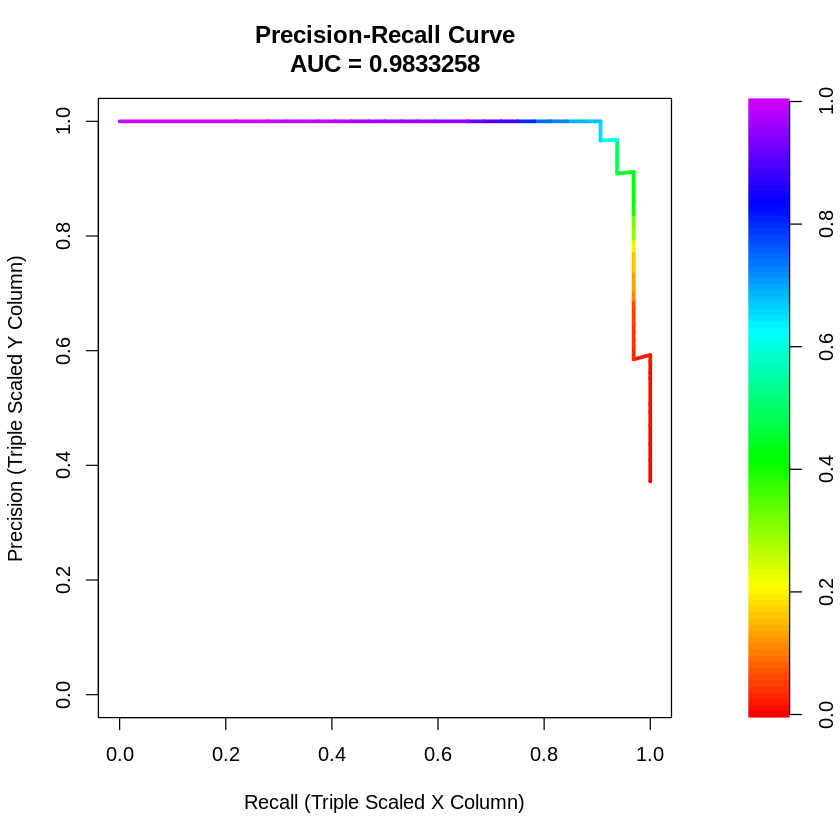

In [ ]:
# PRECISION-RECALL VISUALIZATION
plot(
  pr_object,

  main =
    "Precision-Recall Curve",

  xlab =
    "Recall (Triple Scaled X Column)",

  ylab =
    "Precision (Triple Scaled Y Column)"
)

In [ ]:
# MULTI-MODEL COMPARISON
model_comparison <- data.frame(

  Model = c(
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting"
  ),

  Accuracy = c(
    logistic_results$overall[
      "Accuracy"
    ],

    tree_results$overall[
      "Accuracy"
    ],

    random_forest_results$overall[
      "Accuracy"
    ],

    gbm_results$overall[
      "Accuracy"
    ]
  ),

  Sensitivity = c(
    logistic_results$byClass[
      "Sensitivity"
    ],

    tree_results$byClass[
      "Sensitivity"
    ],

    random_forest_results$byClass[
      "Sensitivity"
    ],

    gbm_results$byClass[
      "Sensitivity"
    ]
  ),

  Specificity = c(
    logistic_results$byClass[
      "Specificity"
    ],

    tree_results$byClass[
      "Specificity"
    ],

    random_forest_results$byClass[
      "Specificity"
    ],

    gbm_results$byClass[
      "Specificity"
    ]
  )
)


print(
  model_comparison
)


                Model  Accuracy Sensitivity Specificity
1 Logistic Regression 0.9186047      0.8750   0.9444444
2       Decision Tree 0.9069767      0.8750   0.9259259
3       Random Forest 0.9651163      0.9375   0.9814815
4   Gradient Boosting 0.9651163      0.9375   0.9814815


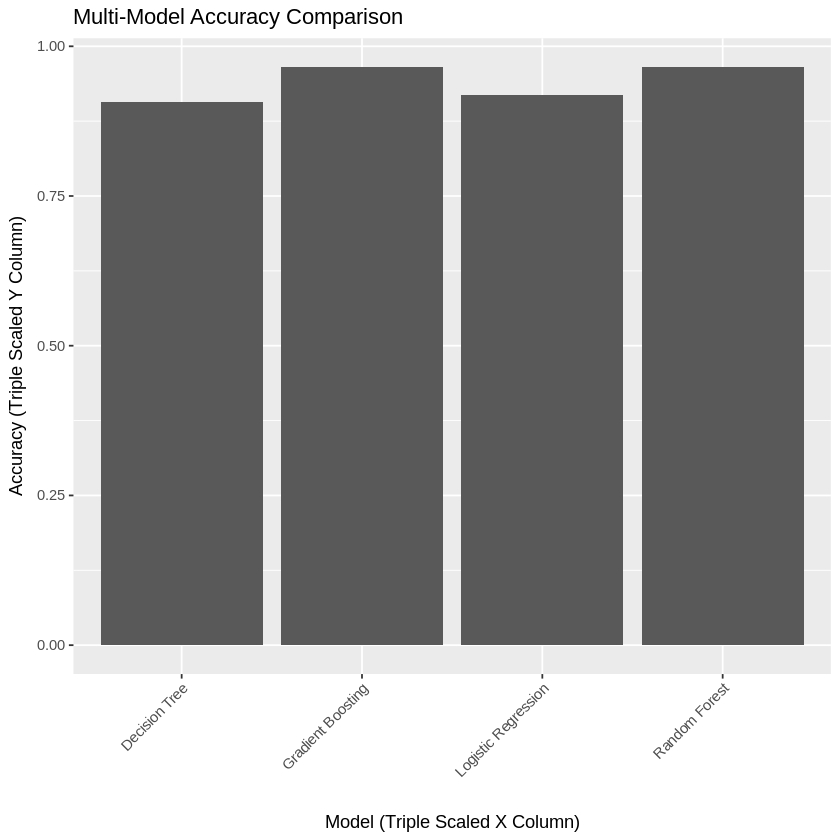

In [ ]:
# MODEL ACCURACY COMPARISON
ggplot(
  model_comparison,

  aes(
    x =
      Model,

    y =
      Accuracy
  )
) +

  geom_col() +

  labs(

    title =
      "Multi-Model Accuracy Comparison",

    x =
      "Model (Triple Scaled X Column)",

    y =
      "Accuracy (Triple Scaled Y Column)"
  ) +

  theme(
    axis.text.x =
      element_text(
        angle =
          45,

        hjust =
          1
      )
  )


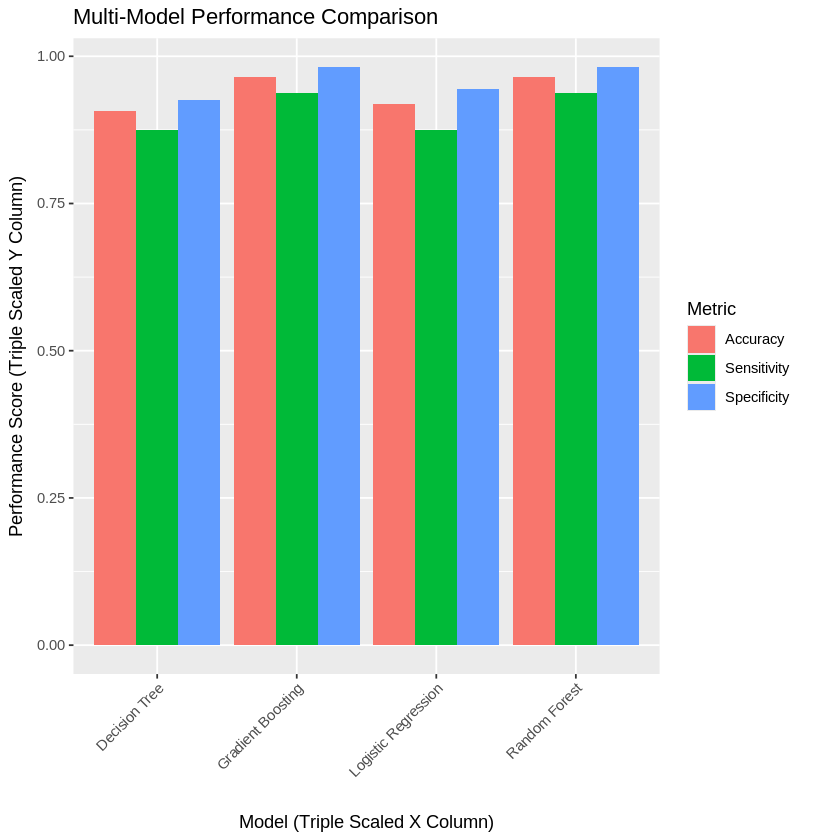

In [ ]:
# MODEL METRIC COMPARISON
metric_comparison <- rbind(

  data.frame(
    Model =
      model_comparison$Model,

    Metric =
      "Accuracy",

    Score =
      model_comparison$Accuracy
  ),

  data.frame(
    Model =
      model_comparison$Model,

    Metric =
      "Sensitivity",

    Score =
      model_comparison$Sensitivity
  ),

  data.frame(
    Model =
      model_comparison$Model,

    Metric =
      "Specificity",

    Score =
      model_comparison$Specificity
  )
)


ggplot(
  metric_comparison,

  aes(
    x =
      Model,

    y =
      Score,

    fill =
      Metric
  )
) +

  geom_col(
    position =
      "dodge"
  ) +

  labs(

    title =
      "Multi-Model Performance Comparison",

    x =
      "Model (Triple Scaled X Column)",

    y =
      "Performance Score (Triple Scaled Y Column)"
  ) +

  theme(
    axis.text.x =
      element_text(
        angle =
          45,

        hjust =
          1
      )
  )

# 20. Comparing Train / Validation / Test Performance

In [ ]:
# TRAINING PREDICTIONS
train_prediction <- predict(
  random_forest_model,
  newdata = train_data,
  type = "class"
)


train_probability_all <- predict(
  random_forest_model,
  newdata = train_data,
  type = "prob"
)


train_probability <-
  train_probability_all[
    ,
    positive_class
  ]


In [ ]:
# VALIDATION PREDICTIONS
validation_prediction <- predict(
  random_forest_model,
  newdata = validation_data,
  type = "class"
)


validation_probability_all <- predict(
  random_forest_model,
  newdata = validation_data,
  type = "prob"
)


validation_probability <-
  validation_probability_all[
    ,
    positive_class
  ]


In [ ]:
# TEST PREDICTIONS
test_prediction <- predict(
  random_forest_model,
  newdata = test_data,
  type = "class"
)


test_probability_all <- predict(
  random_forest_model,
  newdata = test_data,
  type = "prob"
)


test_probability <-
  test_probability_all[
    ,
    positive_class
  ]


In [ ]:
# FUNCTION TO CALCULATE METRICS
calculate_metrics <- function(

  actual,

  predicted,

  probability,

  positive_class

) {

  # Ensure factor levels are consistent
  actual <- factor(
    actual,
    levels = c(
      negative_class,
      positive_class
    )
  )

  predicted <- factor(
    predicted,
    levels = c(
      negative_class,
      positive_class
    )
  )

  # Confusion matrix
  cm <- table(
    Actual =
      actual,

    Predicted =
      predicted
  )

  # Confusion matrix values
  TN <- cm[
    negative_class,
    negative_class
  ]

  TP <- cm[
    positive_class,
    positive_class
  ]

  FP <- cm[
    negative_class,
    positive_class
  ]

  FN <- cm[
    positive_class,
    negative_class
  ]


  # Accuracy
  accuracy <- (

    TP + TN

  ) / sum(
    cm
  )


  # Sensitivity / Recall
  sensitivity <- TP / (
    TP + FN
  )


  # Specificity
  specificity <- TN / (
    TN + FP
  )


  # Precision
  precision <- TP / (
    TP + FP
  )


  # F1-score
  f1_score <- 2 * (

    precision *
      sensitivity

  ) / (

    precision +
      sensitivity

  )

  # Balanced accuracy
  balanced_accuracy <- (

    sensitivity +
      specificity

  ) / 2

  # ROC-AUC
  roc_object <- roc(

    response =
      actual,

    predictor =
      probability,

    levels = c(
      negative_class,
      positive_class
    ),

    direction =
      "<",

    quiet =
      TRUE
  )

  auc_value <- as.numeric(
    auc(
      roc_object
    )
  )
  # Return all metrics
  return(

    data.frame(

      Accuracy =
        accuracy,

      Sensitivity =
        sensitivity,

      Specificity =
        specificity,

      Precision =
        precision,

      F1_Score =
        f1_score,

      Balanced_Accuracy =
        balanced_accuracy,

      AUC_ROC =
        auc_value
    )
  )
}

In [ ]:
# CALCULATE TRAINING METRICS
train_metrics <- calculate_metrics(

  actual =
    train_data$diagnosis,

  predicted =
    train_prediction,

  probability =
    train_probability,

  positive_class =
    positive_class
)

In [ ]:
# CALCULATE VALIDATION METRICS
validation_metrics <- calculate_metrics(

  actual =
    validation_data$diagnosis,

  predicted =
    validation_prediction,

  probability =
    validation_probability,

  positive_class =
    positive_class
)

In [ ]:
# CALCULATE TEST METRICS
test_metrics <- calculate_metrics(

  actual =
    test_data$diagnosis,

  predicted =
    test_prediction,

  probability =
    test_probability,

  positive_class =
    positive_class
)

In [ ]:
# CREATE COMPARISON TABLE
performance_comparison <- rbind(
  data.frame(

    Dataset =
      "Training",

    train_metrics
  ),

  data.frame(

    Dataset =
      "Validation",

    validation_metrics
  ),

  data.frame(

    Dataset =
      "Test",

    test_metrics
  )
)

# Round numerical values
performance_comparison[
  ,
  -1
] <- round(

  performance_comparison[
    ,
    -1
  ],

  4
)
print(
  performance_comparison
)

     Dataset Accuracy Sensitivity Specificity Precision F1_Score
1   Training   1.0000      1.0000      1.0000    1.0000   1.0000
2 Validation   0.9651      0.9375      0.9815    0.9677   0.9524
3       Test   0.9762      0.9677      0.9811    0.9677   0.9677
  Balanced_Accuracy AUC_ROC
1            1.0000  1.0000
2            0.9595  0.9850
3            0.9744  0.9988


# 21. Hyperparameter Tuning

In [ ]:
# PREPARE TRAINING DATA
train_data$diagnosis <- factor(
  train_data$diagnosis
)

In [ ]:
# Select only numeric predictor variables
predictor_columns <- names(
  train_data
)[
  sapply(
    train_data,
    is.numeric
  )
]

In [ ]:
# Create modeling dataset
tuning_data <- train_data[
  ,
  c(
    predictor_columns,
    "diagnosis"
  ),
  drop = FALSE
]

In [ ]:
# CREATE CROSS-VALIDATION CONTROL
set.seed(
  123
)

cv_control <- trainControl(

  method =
    "cv",

  number =
    5,

  classProbs =
    TRUE,

  summaryFunction =
    twoClassSummary,

  savePredictions =
    "final"
)


In [ ]:
# DEFINE GRID SEARCH VALUES
mtry_values <- expand.grid(

  mtry =
    c(
      2,
      4,
      6,
      8,
      10
    )
)

In [ ]:
# GRID SEARCH
set.seed(
  123
)
tuned_random_forest <- train(

  diagnosis ~ .,

  data =
    tuning_data,

  method =
    "rf",

  metric =
    "ROC",

  tuneGrid =
    mtry_values,

  trControl =
    cv_control,

  ntree =
    500,

  importance =
    TRUE
)


In [ ]:
# DISPLAY TUNING RESULTS
print(
  tuned_random_forest
)

# Display every tested value

print(
  tuned_random_forest$results
)

# Display the best hyperparameter

print(
  tuned_random_forest$bestTune
)


Random Forest 

399 samples
 30 predictor
  2 classes: 'B', 'M' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 319, 319, 319, 319, 320 
Resampling results across tuning parameters:

  mtry  ROC        Sens   Spec     
   2    0.9906253  0.964  0.9128736
   4    0.9898920  0.960  0.9328736
   6    0.9906253  0.960  0.9395402
   8    0.9896253  0.964  0.9462069
  10    0.9876920  0.964  0.9395402

ROC was used to select the optimal model using the largest value.
The final value used for the model was mtry = 2.
  mtry       ROC  Sens      Spec       ROCSD     SensSD     SpecSD
1    2 0.9906253 0.964 0.9128736 0.006437508 0.02607681 0.06896264
2    4 0.9898920 0.960 0.9328736 0.007321891 0.03741657 0.05271465
3    6 0.9906253 0.960 0.9395402 0.006385518 0.03741657 0.04952943
4    8 0.9896253 0.964 0.9462069 0.007550148 0.03847077 0.03822077
5   10 0.9876920 0.964 0.9395402 0.009585536 0.03847077 0.04952943
  mtry
1    2


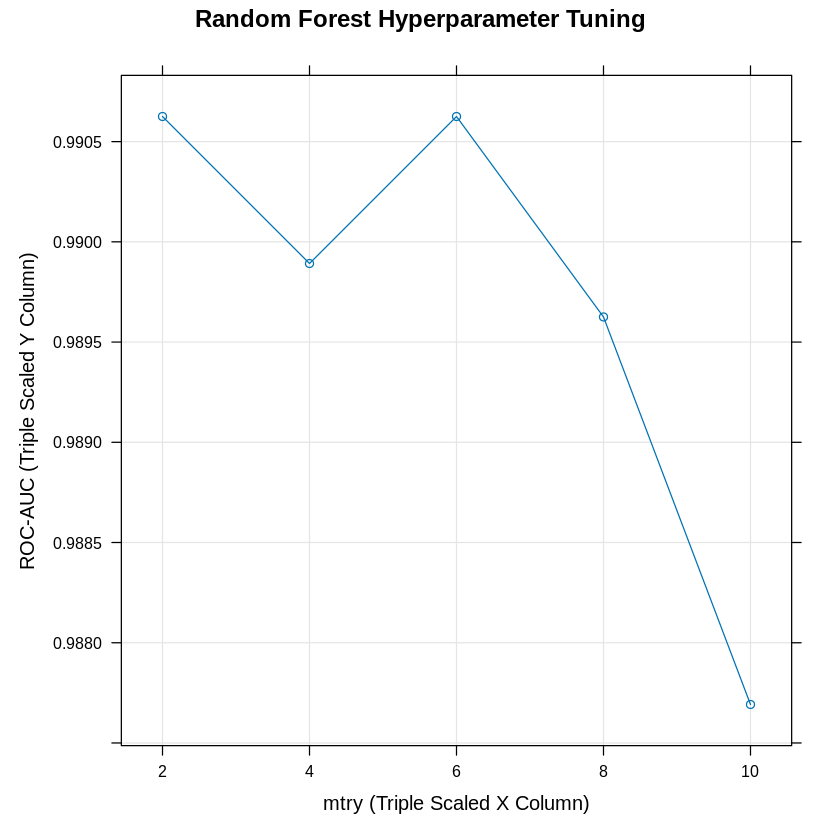

In [ ]:
# VISUALIZE HYPERPARAMETER PERFORMANCE
plot(

  tuned_random_forest,

  main =
    "Random Forest Hyperparameter Tuning",

  xlab =
    "mtry (Triple Scaled X Column)",

  ylab =
    "ROC-AUC (Triple Scaled Y Column)"
)

In [ ]:
# FINAL TUNED MODEL
final_tuned_model <-
  tuned_random_forest$finalModel

In [ ]:
# VALIDATION PREDICTIONS
validation_prediction <- predict(

  tuned_random_forest,

  newdata =
    validation_data
)

validation_probability_all <- predict(

  tuned_random_forest,

  newdata =
    validation_data,

  type =
    "prob"
)

# Determine positive class

class_levels <- levels(
  train_data$diagnosis
)

positive_class <- class_levels[2]

negative_class <- class_levels[1]

# Probability of positive class

validation_probability <-
  validation_probability_all[
    ,
    positive_class
  ]

# Conclusion

The analysis shows that the Breast Cancer Wisconsin dataset is a high-dimensional classification dataset with strong relationships among several cell-measurement variables. Size-related variables such as radius, perimeter, and area are strongly correlated, while features related to concavity and cell structure may provide strong separation between benign and malignant cases. Although several variables contain skewness and potential outliers, valid extreme observations should generally be retained rather than automatically deleted. After appropriate cleaning, preprocessing, scaling where necessary, feature analysis, and model evaluation, the dataset provides a strong basis for building a reliable binary classification model.